In [138]:
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt

# Build path relative to this notebook's folder
file_path = Path("DS0001") / "38304-0001-Data.tsv"

df = pd.read_csv(file_path, sep="\t")

print(f"Loaded {len(df):,} rows and {df.shape[1]} columns")
df.head()

Loaded 1,495 rows and 234 columns


,STARTDATE,ENDDATE,STATUS,IPADDRESS,PROGRESS,DURATION__IN_SECONDS_,TIME,TIME_FLAG,FINISHED,RECORDEDDATE,...,QOL,PH,PSY,SOCREL,ENV,ADAMSPSYCH_MEAN,ADAMSEMO_MEAN,ADAMSSOC_MEAN,ADAMSSPIR_MEAN,ADAMSINT_MEAN
0,27-MAY-2020 08:01:31,27-MAY-2020 08:12:32,0,*******,100,661,11.016666,0,1,27-MAY-2020 08:12:32,...,100.0,92.85713958741,83.333336,83.333336,100.000,4.333333,3.666667,4.000000,3.500000,4.500000
1,27-MAY-2020 07:58:38,27-MAY-2020 08:13:07,0,*******,100,869,14.483334,0,1,27-MAY-2020 08:13:07,...,87.5,71.4285736084,79.166664,75.000000,100.000,3.833333,3.833333,3.500000,4.000000,3.833333
2,27-MAY-2020 07:59:18,27-MAY-2020 08:13:30,0,*******,100,852,14.200000,0,1,27-MAY-2020 08:13:30,...,87.5,92.85713958741,83.333336,100.000000,100.000,4.166667,4.166667,4.166667,4.333333,4.166667
3,27-MAY-2020 07:58:41,27-MAY-2020 08:14:22,0,*******,100,941,15.683333,0,1,27-MAY-2020 08:14:23,...,87.5,85.7142868042,91.666664,75.000000,90.625,4.500000,4.500000,3.333333,4.333333,4.833333
4,27-MAY-2020 08:02:02,27-MAY-2020 08:14:36,0,*******,100,754,12.566667,0,1,27-MAY-2020 08:14:38,...,37.5,25,54.166668,16.666666,34.375,3.333333,4.166667,3.666667,3.000000,3.333333


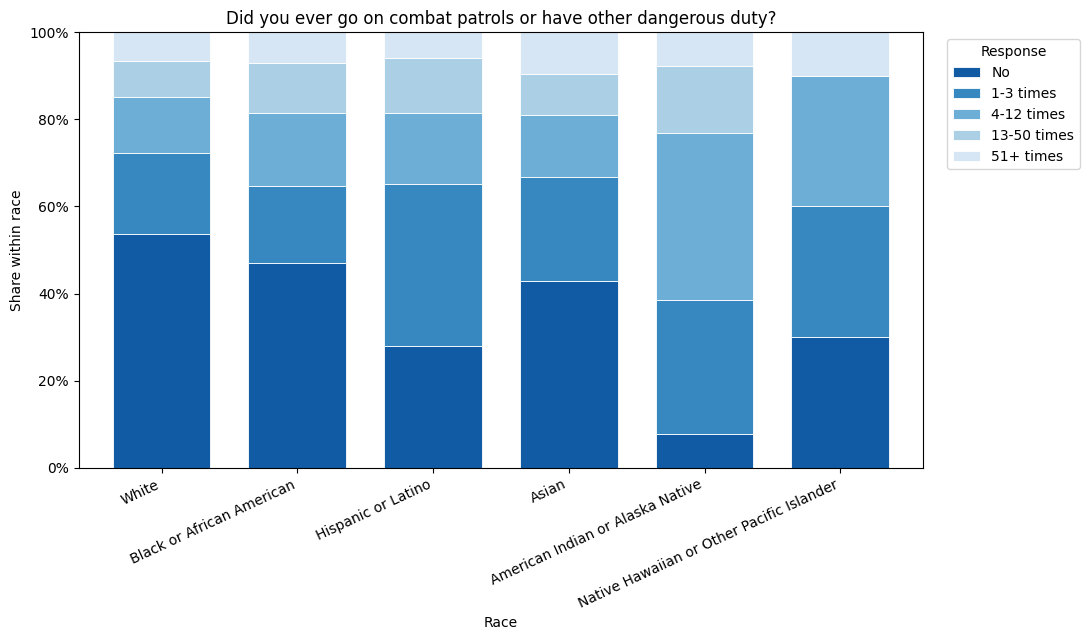

In [139]:
race_map = {
    1: "White",
    2: "Black or African American",
    3: "Hispanic or Latino",
    4: "Asian",
    5: "American Indian or Alaska Native",
    6: "Native Hawaiian or Other Pacific Islander",
}

# CES_1: "Did you ever go on combat patrols or have other dangerous duty?"
ces_response_labels = {
    1: "No",
    2: "1-3 times",
    3: "4-12 times",
    4: "13-50 times",
    5: "51+ times",
}

ces_df = df[["RACE", "CES_1"]].copy()
ces_df["RACE"] = pd.to_numeric(ces_df["RACE"], errors="coerce")
ces_df["CES_1"] = pd.to_numeric(ces_df["CES_1"], errors="coerce")
ces_df = ces_df.dropna(subset=["RACE", "CES_1"])
ces_df = ces_df[ces_df["RACE"].isin(race_map.keys())].copy()
ces_df["RACE_LABEL"] = ces_df["RACE"].astype(int).map(race_map)

race_order = [race_map[k] for k in sorted(race_map.keys())]
response_order = sorted(ces_response_labels.keys())

ct = pd.crosstab(ces_df["RACE_LABEL"], ces_df["CES_1"])
ct = ct.reindex(index=race_order, fill_value=0)
ct = ct.reindex(columns=response_order, fill_value=0)

# Proportions within each race (each bar sums to 1)
prop = ct.div(ct.sum(axis=1).replace(0, float("nan")), axis=0).fillna(0)
prop.columns = [ces_response_labels[c] for c in prop.columns]

fig, ax = plt.subplots(figsize=(11, 6.5))
colors = sns.color_palette("Blues_r", n_colors=len(prop.columns))
prop.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=colors,
    width=0.72,
    edgecolor="white",
    linewidth=0.6,
)
ax.set_ylabel("Share within race")
ax.set_xlabel("Race")
ax.set_title(
    "Did you ever go on combat patrols or have other dangerous duty?"
)
ax.legend(title="Response", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


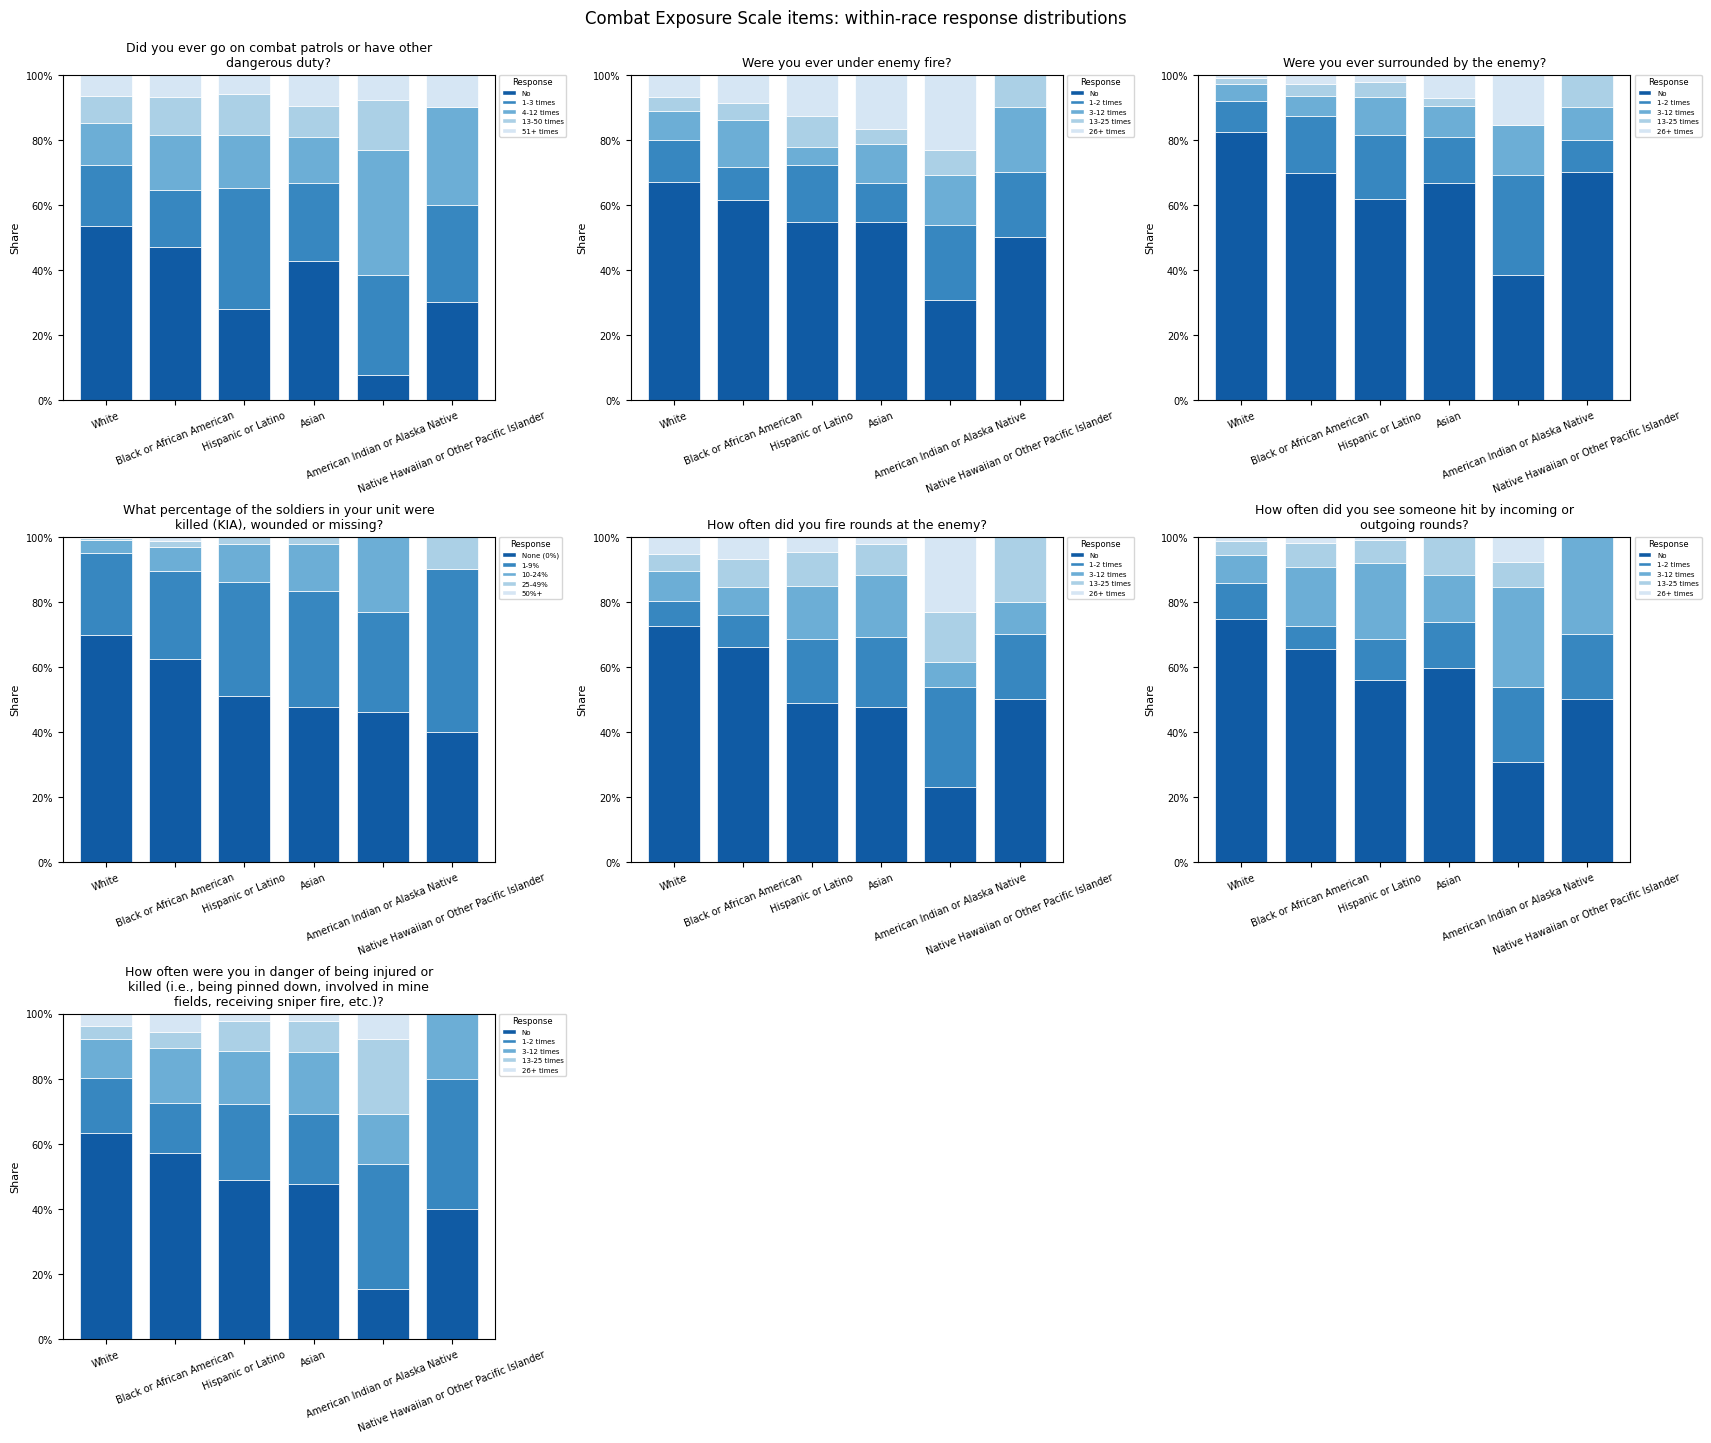

In [140]:
import textwrap

# All CES_* items: within-race 100% stacked bars (one subplot per item)
race_map = {
    1: "White",
    2: "Black or African American",
    3: "Hispanic or Latino",
    4: "Asian",
    5: "American Indian or Alaska Native",
    6: "Native Hawaiian or Other Pacific Islander",
}

# Response anchors differ by item on the Combat Exposure Scale
FREQ_PATROL = {
    1: "No",
    2: "1-3 times",
    3: "4-12 times",
    4: "13-50 times",
    5: "51+ times",
}
FREQ_STANDARD = {
    1: "No",
    2: "1-2 times",
    3: "3-12 times",
    4: "13-25 times",
    5: "26+ times",
}
PCT_UNIT = {
    1: "None (0%)",
    2: "1-9%",
    3: "10-24%",
    4: "25-49%",
    5: "50%+",
}

CES_SPECS = [
    ("CES_1", "Did you ever go on combat patrols or have other dangerous duty?", FREQ_PATROL),
    ("CES_2", "Were you ever under enemy fire?", FREQ_STANDARD),
    ("CES_3", "Were you ever surrounded by the enemy?", FREQ_STANDARD),
    (
        "CES_4",
        "What percentage of the soldiers in your unit were killed (KIA), wounded or missing?",
        PCT_UNIT,
    ),
    ("CES_5", "How often did you fire rounds at the enemy?", FREQ_STANDARD),
    (
        "CES_6",
        "How often did you see someone hit by incoming or outgoing rounds?",
        FREQ_STANDARD,
    ),
    (
        "CES_7",
        "How often were you in danger of being injured or killed "
        "(i.e., being pinned down, involved in mine fields, receiving sniper fire, etc.)?",
        FREQ_STANDARD,
    ),
]

race_order = [race_map[k] for k in sorted(race_map.keys())]


def ces_stacked_by_race(ax, data, col, response_labels):
    sub = data[["RACE", col]].copy()
    sub["RACE"] = pd.to_numeric(sub["RACE"], errors="coerce")
    sub[col] = pd.to_numeric(sub[col], errors="coerce")
    sub = sub.dropna(subset=["RACE", col])
    sub = sub[sub["RACE"].isin(race_map.keys())].copy()
    sub["RACE_LABEL"] = sub["RACE"].astype(int).map(race_map)
    order = sorted(response_labels.keys())
    ct = pd.crosstab(sub["RACE_LABEL"], sub[col])
    ct = ct.reindex(index=race_order, fill_value=0)
    ct = ct.reindex(columns=order, fill_value=0)
    prop = ct.div(ct.sum(axis=1).replace(0, float("nan")), axis=0).fillna(0)
    prop.columns = [response_labels[c] for c in prop.columns]
    colors = sns.color_palette("Blues_r", n_colors=len(prop.columns))
    prop.plot(
        kind="bar",
        stacked=True,
        ax=ax,
        color=colors,
        width=0.75,
        edgecolor="white",
        linewidth=0.5,
        legend=False,
    )
    ax.set_ylim(0, 1)
    ax.set_ylabel("Share", fontsize=8)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=22, labelsize=7)
    ax.tick_params(axis="y", labelsize=7)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
    handles = [
        plt.Rectangle((0, 0), 1, 1, facecolor=colors[i], edgecolor="white")
        for i in range(len(prop.columns))
    ]
    ax.legend(
        handles,
        list(prop.columns),
        loc="upper left",
        bbox_to_anchor=(1.01, 1),
        fontsize=5,
        title="Response",
        title_fontsize=6,
        frameon=True,
        borderaxespad=0.0,
    )


fig, axes = plt.subplots(3, 3, figsize=(17, 14), constrained_layout=True)
axes_flat = axes.flatten()

for i, (col, title, labels) in enumerate(CES_SPECS):
    ax = axes_flat[i]
    ces_stacked_by_race(ax, df, col, labels)
    ax.set_title("\n".join(textwrap.wrap(title, width=52)), fontsize=9)

for j in range(len(CES_SPECS), len(axes_flat)):
    axes_flat[j].set_visible(False)

fig.suptitle("Combat Exposure Scale items: within-race response distributions", fontsize=12, y=1.02)
plt.show()


Some racial groups—particularly American Indian / Alaska Native respondents—report consistently higher levels of combat exposure across multiple measures, while White respondents report the lowest levels, with other groups falling in between.

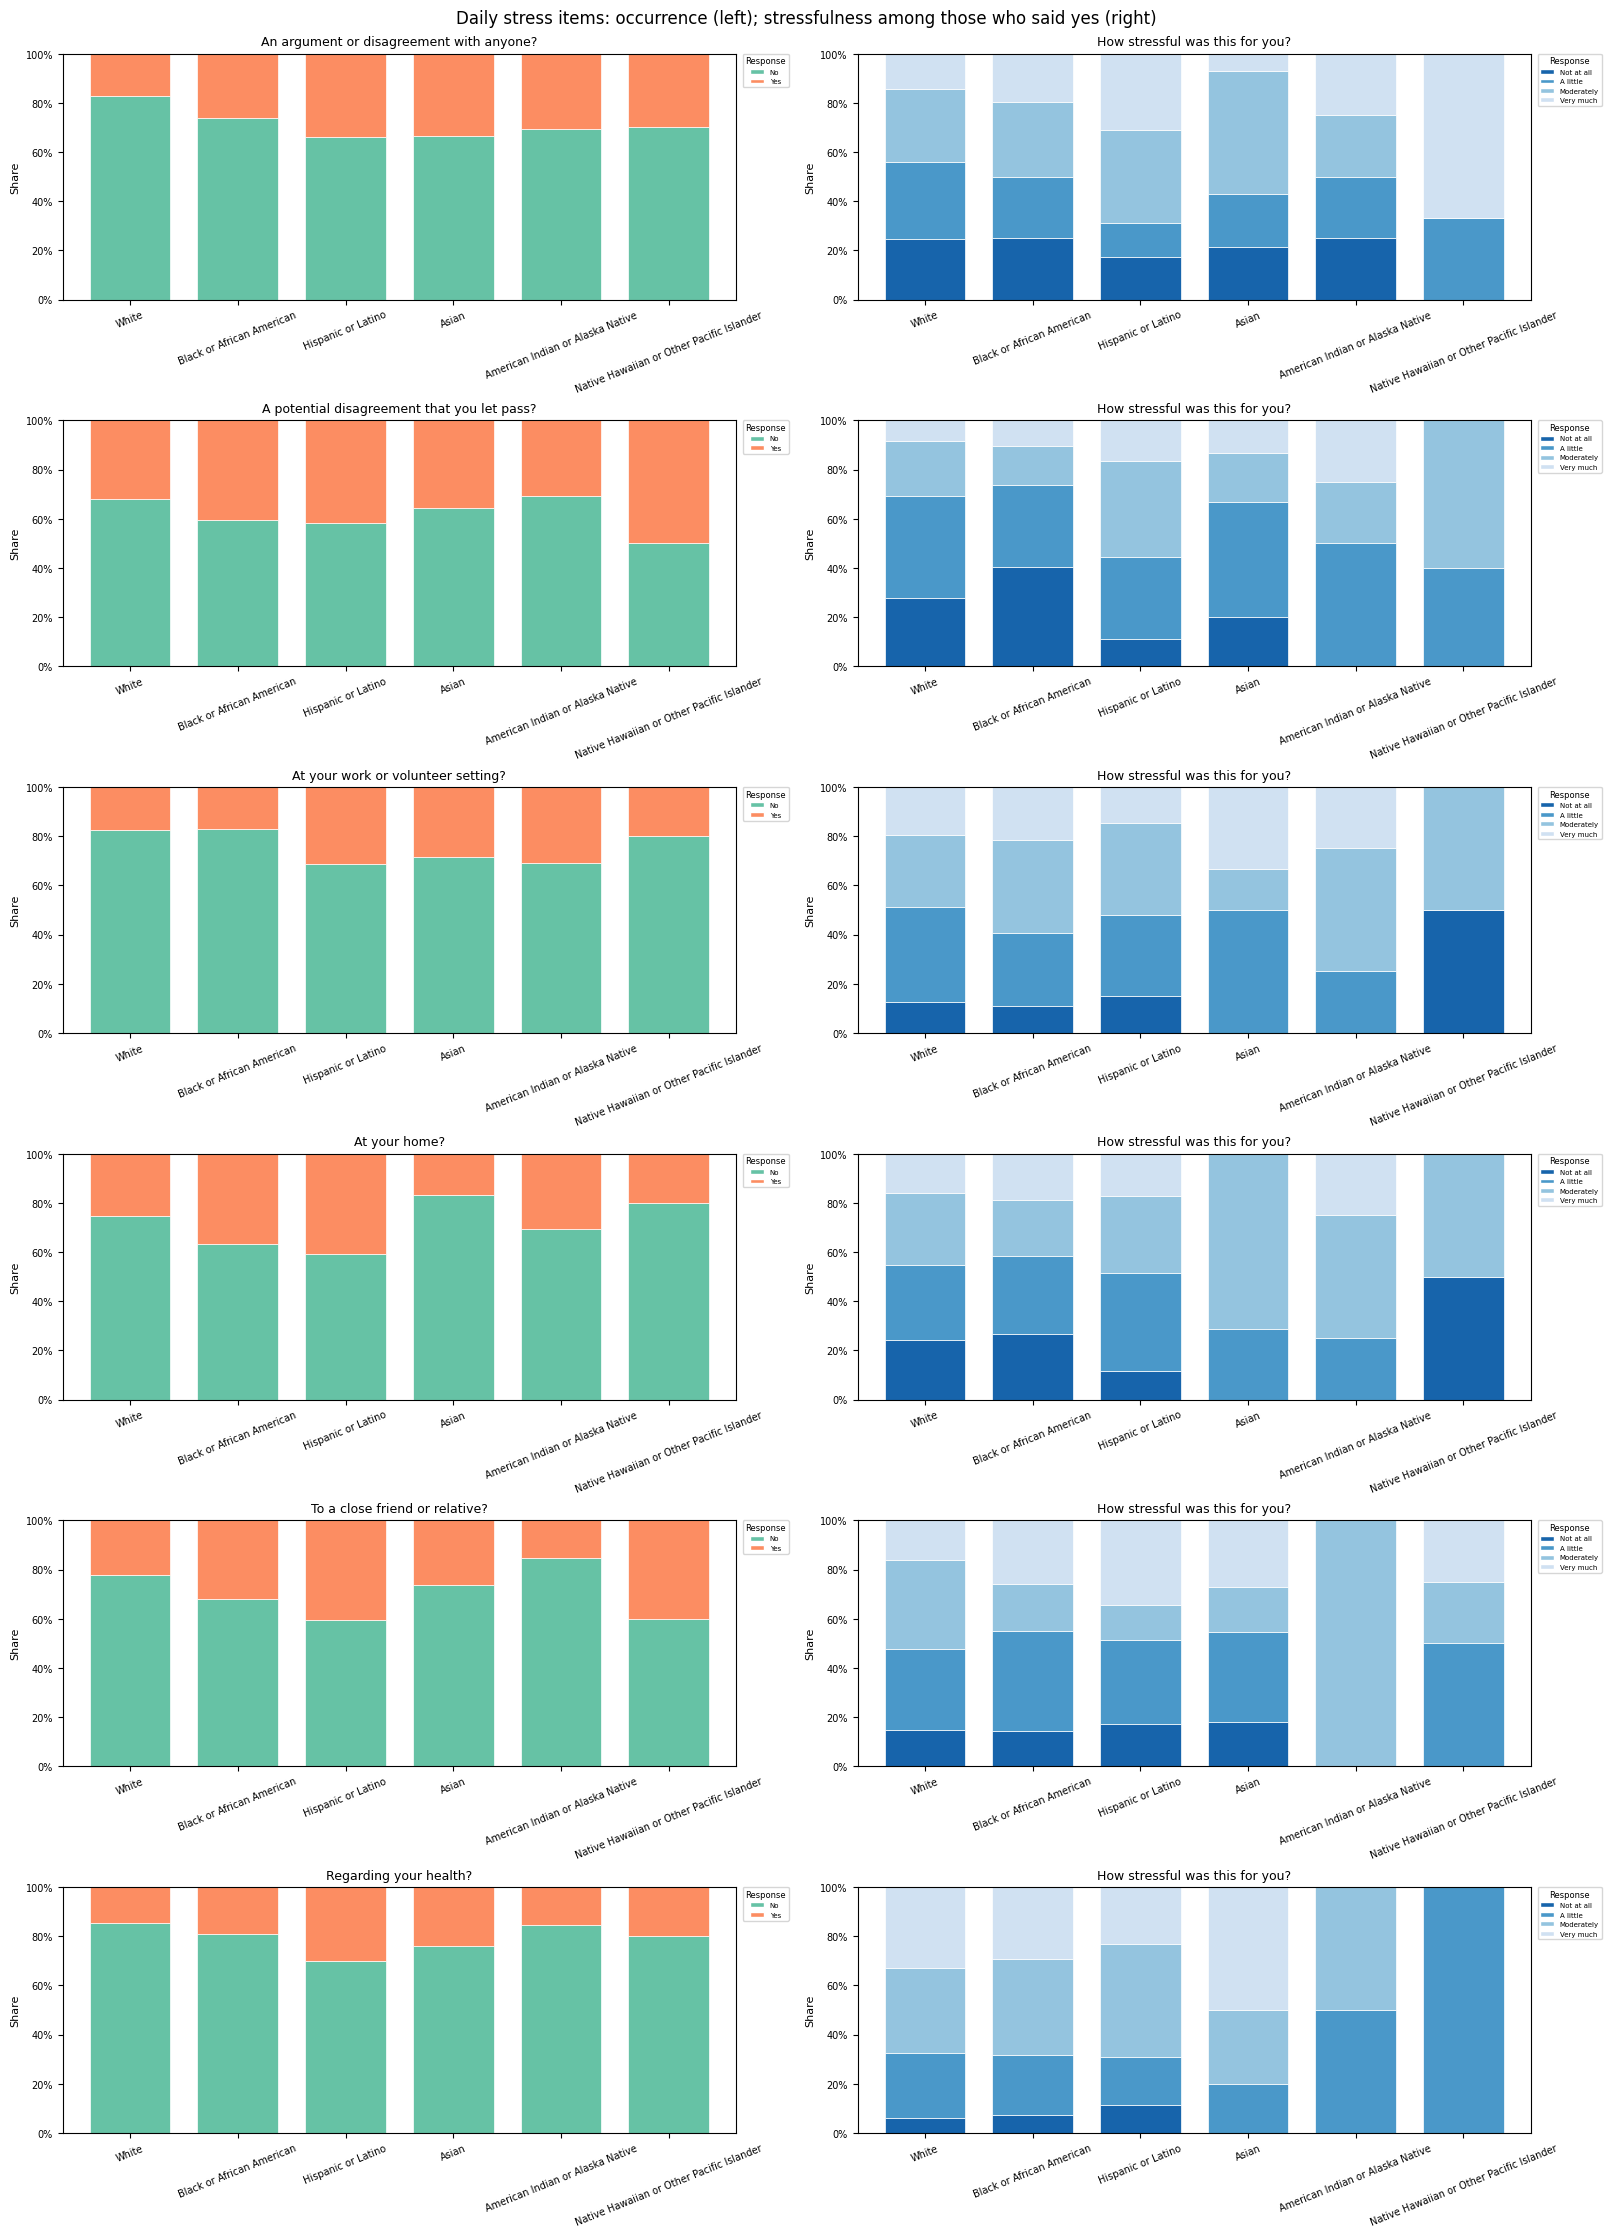

In [141]:
import textwrap

# Daily stressors: each row = one domain; left = occurrence (STRESS_n), right = stressfulness (STRESS_nA)
race_map = {
    1: "White",
    2: "Black or African American",
    3: "Hispanic or Latino",
    4: "Asian",
    5: "American Indian or Alaska Native",
    6: "Native Hawaiian or Other Pacific Islander",
}

STRESS_OCC_LABELS = {0: "No", 1: "Yes"}
STRESS_A_LABELS = {
    1: "Not at all",
    2: "A little",
    3: "Moderately",
    4: "Very much",
}

STRESS_SPECS = [
    ("STRESS_1", "STRESS_1A", "An argument or disagreement with anyone?"),
    ("STRESS_2", "STRESS_2A", "A potential disagreement that you let pass?"),
    ("STRESS_3", "STRESS_3A", "At your work or volunteer setting?"),
    ("STRESS_4", "STRESS_4A", "At your home?"),
    ("STRESS_5", "STRESS_5A", "To a close friend or relative?"),
    ("STRESS_6", "STRESS_6A", "Regarding your health?"),
]

STRESS_A_PROMPT = "How stressful was this for you?"

race_order = [race_map[k] for k in sorted(race_map.keys())]


def stress_occ_stacked(ax, data, col, response_labels):
    sub = data[["RACE", col]].copy()
    sub["RACE"] = pd.to_numeric(sub["RACE"], errors="coerce")
    sub[col] = pd.to_numeric(sub[col], errors="coerce")
    sub = sub.dropna(subset=["RACE", col])
    sub = sub[sub["RACE"].isin(race_map.keys())].copy()
    sub["RACE_LABEL"] = sub["RACE"].astype(int).map(race_map)
    sub["cat"] = sub[col].astype(int).map(response_labels)
    order = [response_labels[k] for k in sorted(response_labels.keys())]
    ct = pd.crosstab(sub["RACE_LABEL"], sub["cat"])
    ct = ct.reindex(index=race_order, fill_value=0)
    ct = ct.reindex(columns=order, fill_value=0)
    prop = ct.div(ct.sum(axis=1).replace(0, float("nan")), axis=0).fillna(0)
    colors = sns.color_palette("Set2", n_colors=len(prop.columns))
    prop.plot(
        kind="bar",
        stacked=True,
        ax=ax,
        color=colors,
        width=0.75,
        edgecolor="white",
        linewidth=0.5,
        legend=False,
    )
    ax.set_ylim(0, 1)
    ax.set_ylabel("Share", fontsize=8)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=22, labelsize=7)
    ax.tick_params(axis="y", labelsize=7)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
    handles = [
        plt.Rectangle((0, 0), 1, 1, facecolor=colors[i], edgecolor="white")
        for i in range(len(prop.columns))
    ]
    ax.legend(
        handles,
        list(prop.columns),
        loc="upper left",
        bbox_to_anchor=(1.01, 1),
        fontsize=5,
        title="Response",
        title_fontsize=6,
        frameon=True,
        borderaxespad=0.0,
    )


def stress_a_stacked(ax, data, col_yes, col_a, a_labels):
    sub = data[["RACE", col_yes, col_a]].copy()
    sub["RACE"] = pd.to_numeric(sub["RACE"], errors="coerce")
    sub[col_yes] = pd.to_numeric(sub[col_yes], errors="coerce")
    sub[col_a] = pd.to_numeric(sub[col_a], errors="coerce")
    sub = sub.dropna(subset=["RACE", col_yes])
    sub = sub[sub["RACE"].isin(race_map.keys())].copy()
    # Only respondents who endorsed the stressor (drops "Not applicable" / non-events)
    sub = sub[sub[col_yes] == 1].copy()
    sub["RACE_LABEL"] = sub["RACE"].astype(int).map(race_map)

    def a_category(row):
        if pd.isna(row[col_a]):
            return "Missing"
        k = int(row[col_a])
        return a_labels.get(k, str(k))

    sub["cat"] = sub.apply(a_category, axis=1)
    cat_order = [a_labels[k] for k in sorted(a_labels.keys())] + ["Missing"]
    present = [c for c in cat_order if c in sub["cat"].values]
    ct = pd.crosstab(sub["RACE_LABEL"], sub["cat"])
    ct = ct.reindex(index=race_order, fill_value=0)
    ct = ct.reindex(columns=present, fill_value=0)
    prop = ct.div(ct.sum(axis=1).replace(0, float("nan")), axis=0).fillna(0)
    colors = sns.color_palette("Blues_r", n_colors=len(prop.columns))
    prop.plot(
        kind="bar",
        stacked=True,
        ax=ax,
        color=colors,
        width=0.75,
        edgecolor="white",
        linewidth=0.5,
        legend=False,
    )
    ax.set_ylim(0, 1)
    ax.set_ylabel("Share", fontsize=8)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=22, labelsize=7)
    ax.tick_params(axis="y", labelsize=7)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
    handles = [
        plt.Rectangle((0, 0), 1, 1, facecolor=colors[i], edgecolor="white")
        for i in range(len(prop.columns))
    ]
    ax.legend(
        handles,
        list(prop.columns),
        loc="upper left",
        bbox_to_anchor=(1.01, 1),
        fontsize=5,
        title="Response",
        title_fontsize=6,
        frameon=True,
        borderaxespad=0.0,
    )


fig, axes = plt.subplots(6, 2, figsize=(16, 22), constrained_layout=True)

for i, (col, col_a, q) in enumerate(STRESS_SPECS):
    stress_occ_stacked(axes[i, 0], df, col, STRESS_OCC_LABELS)
    axes[i, 0].set_title("\\n".join(textwrap.wrap(q, width=48)), fontsize=9)
    stress_a_stacked(axes[i, 1], df, col, col_a, STRESS_A_LABELS)
    axes[i, 1].set_title("\\n".join(textwrap.wrap(STRESS_A_PROMPT, width=48)), fontsize=9)

fig.suptitle(
    "Daily stress items: occurrence (left); stressfulness among those who said yes (right)",
    fontsize=12,
    y=1.01,
)
plt.show()


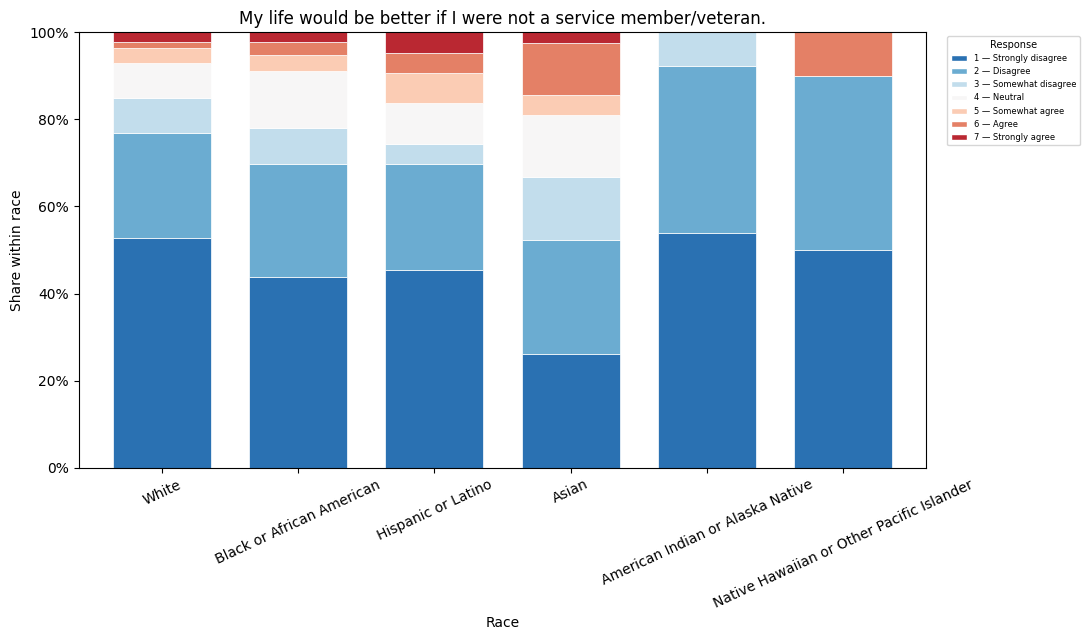

In [142]:
# DD_1 vs race (within-race distribution, 100% stacked bars)
race_map = {
    1: "White",
    2: "Black or African American",
    3: "Hispanic or Latino",
    4: "Asian",
    5: "American Indian or Alaska Native",
    6: "Native Hawaiian or Other Pacific Islander",
}

# 7-point Likert for agreement with the item (edit labels if your codebook differs)
dd1_labels = {
    1: "1 — Strongly disagree",
    2: "2 — Disagree",
    3: "3 — Somewhat disagree",
    4: "4 — Neutral",
    5: "5 — Somewhat agree",
    6: "6 — Agree",
    7: "7 — Strongly agree",
}

q_dd1 = "My life would be better if I were not a service member/veteran."

race_order = [race_map[k] for k in sorted(race_map.keys())]
order = sorted(dd1_labels.keys())

sub = df[["RACE", "DD_1"]].copy()
sub["RACE"] = pd.to_numeric(sub["RACE"], errors="coerce")
sub["DD_1"] = pd.to_numeric(sub["DD_1"], errors="coerce")
sub = sub.dropna(subset=["RACE", "DD_1"])
sub = sub[sub["RACE"].isin(race_map.keys())].copy()
sub["RACE_LABEL"] = sub["RACE"].astype(int).map(race_map)

ct = pd.crosstab(sub["RACE_LABEL"], sub["DD_1"])
ct = ct.reindex(index=race_order, fill_value=0)
ct = ct.reindex(columns=order, fill_value=0)
prop = ct.div(ct.sum(axis=1).replace(0, float("nan")), axis=0).fillna(0)
prop.columns = [dd1_labels[c] for c in prop.columns]

fig, ax = plt.subplots(figsize=(11, 6.5))
colors = sns.color_palette("RdBu_r", n_colors=len(prop.columns))
prop.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=colors,
    width=0.72,
    edgecolor="white",
    linewidth=0.5,
    legend=False,
)
ax.set_ylim(0, 1)
ax.set_ylabel("Share within race")
ax.set_xlabel("Race")
ax.set_title(q_dd1)
ax.tick_params(axis="x", rotation=25)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
handles = [
    plt.Rectangle((0, 0), 1, 1, facecolor=colors[i], edgecolor="white")
    for i in range(len(prop.columns))
]
ax.legend(
    handles,
    list(prop.columns),
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    fontsize=6,
    title="Response",
    title_fontsize=7,
)
plt.tight_layout()
plt.show()


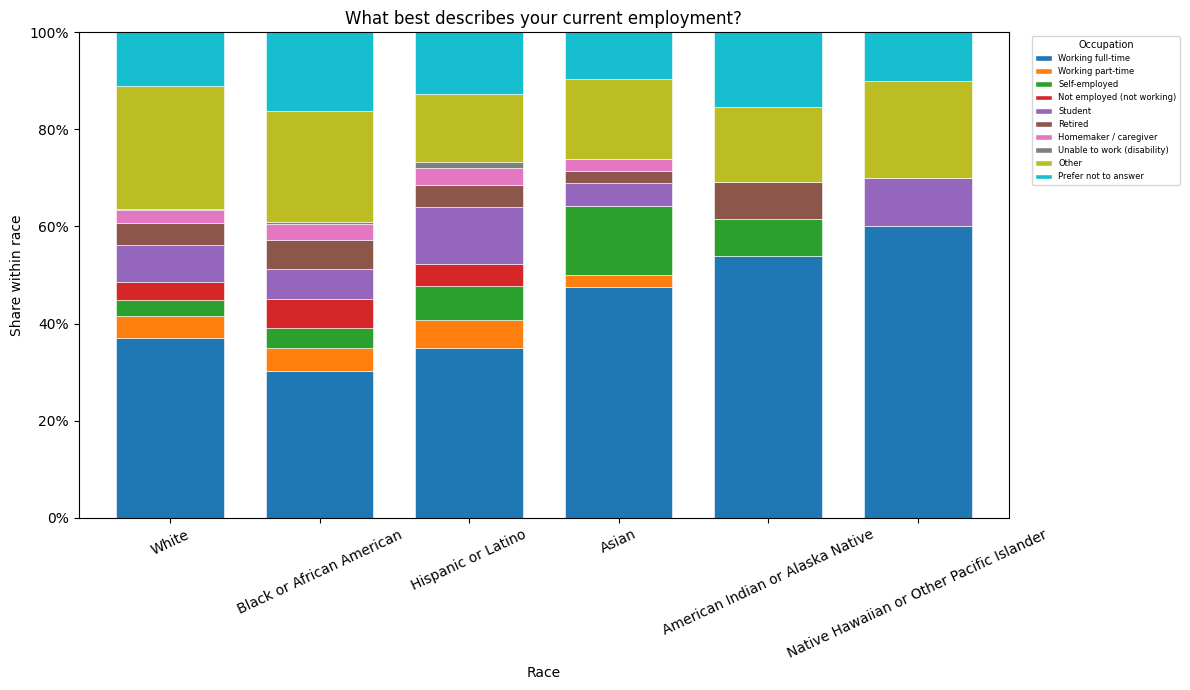

In [143]:
# OCCUPATION vs race (within-race distribution, 100% stacked bars)
# Codes 1–10: labels are typical employment categories — confirm against your ICPSR codebook / questionnaire.
race_map = {
    1: "White",
    2: "Black or African American",
    3: "Hispanic or Latino",
    4: "Asian",
    5: "American Indian or Alaska Native",
    6: "Native Hawaiian or Other Pacific Islander",
}

occupation_labels = {
    1: "Working full-time",
    2: "Working part-time",
    3: "Self-employed",
    4: "Not employed (not working)",
    5: "Student",
    6: "Retired",
    7: "Homemaker / caregiver",
    8: "Unable to work (disability)",
    9: "Other",
    10: "Prefer not to answer",
}

title_q = "What best describes your current employment?"

race_order = [race_map[k] for k in sorted(race_map.keys())]
code_order = sorted(occupation_labels.keys())

sub = df[["RACE", "OCCUPATION"]].copy()
sub["RACE"] = pd.to_numeric(sub["RACE"], errors="coerce")
sub["OCCUPATION"] = pd.to_numeric(sub["OCCUPATION"], errors="coerce")
sub = sub.dropna(subset=["RACE", "OCCUPATION"])
sub = sub[sub["RACE"].isin(race_map.keys())].copy()
sub["RACE_LABEL"] = sub["RACE"].astype(int).map(race_map)

ct = pd.crosstab(sub["RACE_LABEL"], sub["OCCUPATION"])
ct = ct.reindex(index=race_order, fill_value=0)
ct = ct.reindex(columns=code_order, fill_value=0)
prop = ct.div(ct.sum(axis=1).replace(0, float("nan")), axis=0).fillna(0)
prop.columns = [occupation_labels[c] for c in prop.columns]

fig, ax = plt.subplots(figsize=(12, 7))
colors = sns.color_palette("tab10", n_colors=10)
prop.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=colors,
    width=0.72,
    edgecolor="white",
    linewidth=0.4,
    legend=False,
)
ax.set_ylim(0, 1)
ax.set_ylabel("Share within race")
ax.set_xlabel("Race")
ax.set_title(title_q)
ax.tick_params(axis="x", rotation=25)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
handles = [
    plt.Rectangle((0, 0), 1, 1, facecolor=colors[i], edgecolor="white")
    for i in range(len(prop.columns))
]
ax.legend(
    handles,
    list(prop.columns),
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    fontsize=6,
    title="Occupation",
    title_fontsize=7,
)
plt.tight_layout()
plt.show()


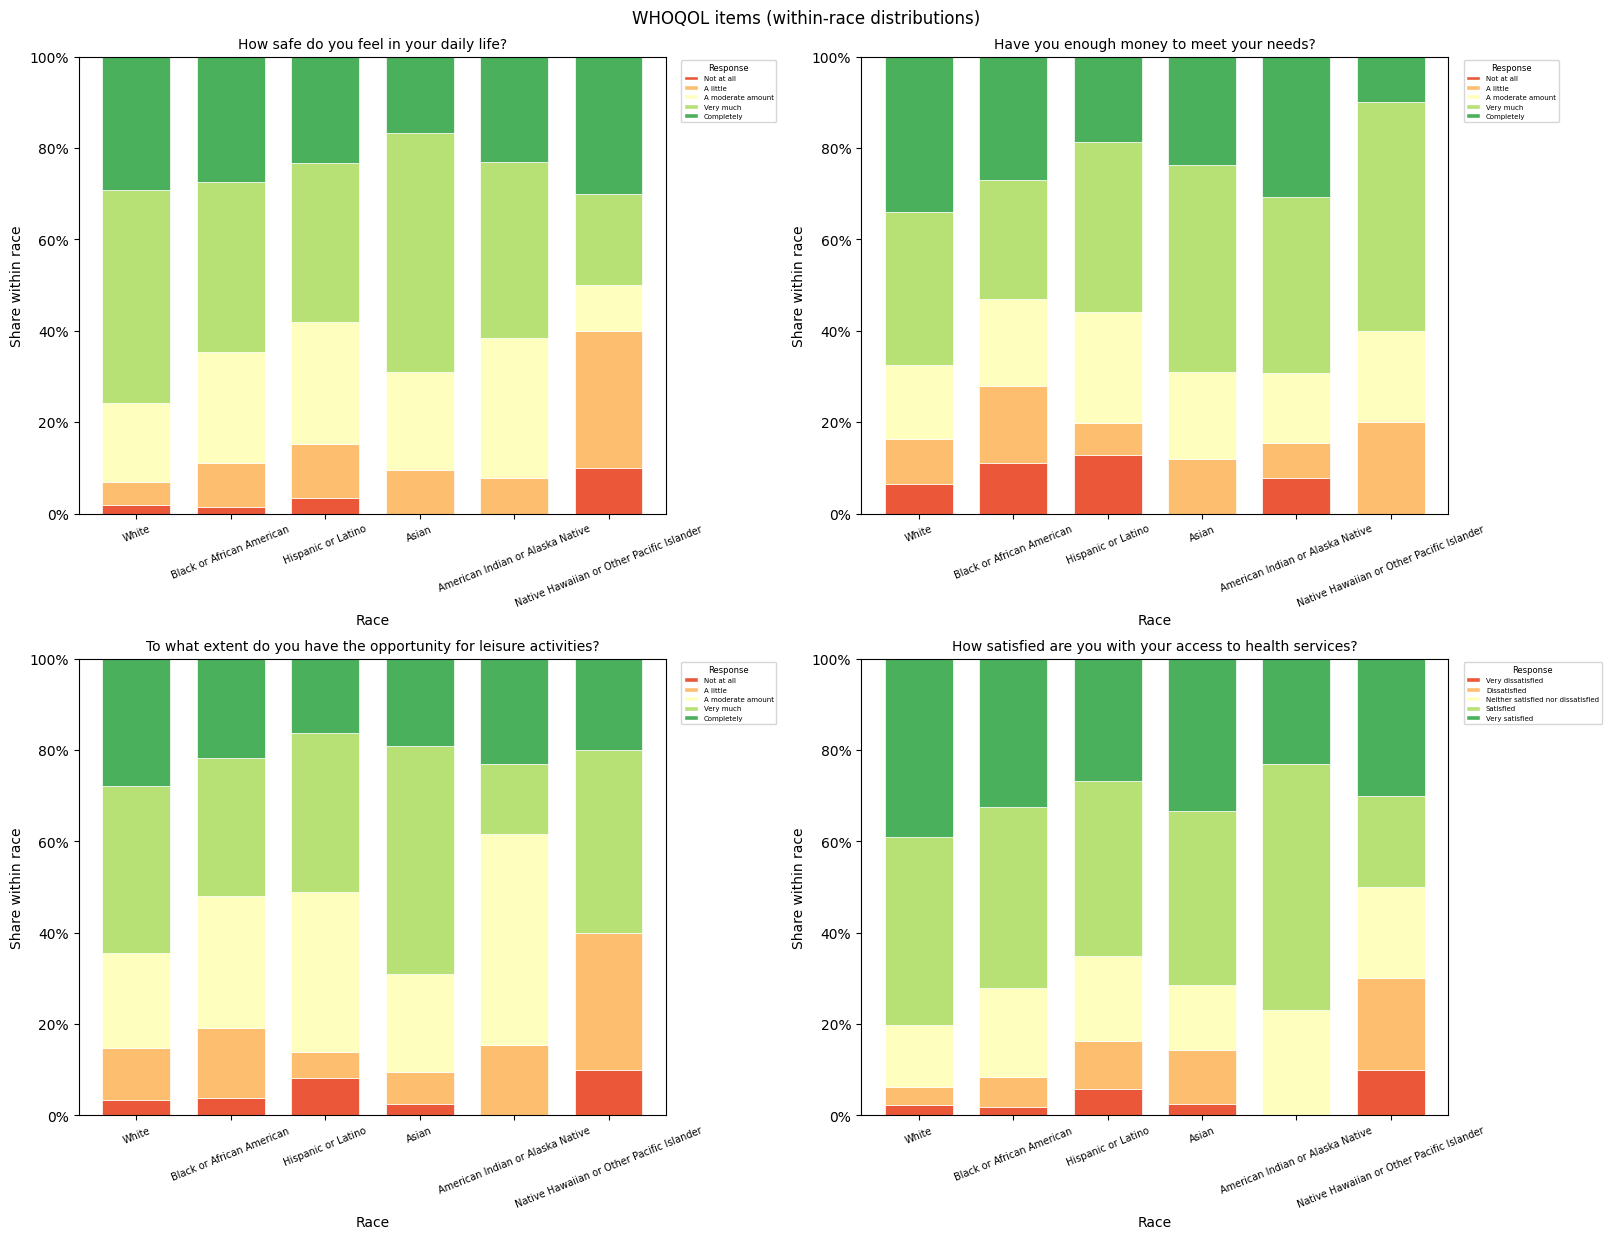

In [144]:
# WHO8, WHO12, WHO14, WHO24 vs race (2×2 grid, 100% stacked bars within race)
race_map = {
    1: "White",
    2: "Black or African American",
    3: "Hispanic or Latino",
    4: "Asian",
    5: "American Indian or Alaska Native",
    6: "Native Hawaiian or Other Pacific Islander",
}

# 5-point WHOQOL-style extent (WHO8, 12, 14 — confirm against codebook)
who5_labels = {
    1: "Not at all",
    2: "A little",
    3: "A moderate amount",
    4: "Very much",
    5: "Completely",
}

# 5-point satisfaction (WHO24 — confirm against codebook)
who24_labels = {
    1: "Very dissatisfied",
    2: "Dissatisfied",
    3: "Neither satisfied nor dissatisfied",
    4: "Satisfied",
    5: "Very satisfied",
}

WHO_ITEMS = [
    ("WHO8", "How safe do you feel in your daily life?", who5_labels),
    ("WHO12", "Have you enough money to meet your needs?", who5_labels),
    (
        "WHO14",
        "To what extent do you have the opportunity for leisure activities?",
        who5_labels,
    ),
    (
        "WHO24",
        "How satisfied are you with your access to health services?",
        who24_labels,
    ),
]

race_order = [race_map[k] for k in sorted(race_map.keys())]


def who_stacked_race(ax, data, col, title, labels):
    order = sorted(labels.keys())
    sub = data[["RACE", col]].copy()
    sub["RACE"] = pd.to_numeric(sub["RACE"], errors="coerce")
    sub[col] = pd.to_numeric(sub[col], errors="coerce")
    sub = sub.dropna(subset=["RACE", col])
    sub = sub[sub["RACE"].isin(race_map.keys())].copy()
    sub["RACE_LABEL"] = sub["RACE"].astype(int).map(race_map)
    ct = pd.crosstab(sub["RACE_LABEL"], sub[col])
    ct = ct.reindex(index=race_order, fill_value=0)
    ct = ct.reindex(columns=order, fill_value=0)
    prop = ct.div(ct.sum(axis=1).replace(0, float("nan")), axis=0).fillna(0)
    prop.columns = [labels[c] for c in prop.columns]
    colors = sns.color_palette("RdYlGn", n_colors=len(prop.columns))
    prop.plot(
        kind="bar",
        stacked=True,
        ax=ax,
        color=colors,
        width=0.72,
        edgecolor="white",
        linewidth=0.5,
        legend=False,
    )
    ax.set_ylim(0, 1)
    ax.set_ylabel("Share within race")
    ax.set_xlabel("Race")
    ax.set_title(title, fontsize=10)
    ax.tick_params(axis="x", rotation=22, labelsize=7)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
    handles = [
        plt.Rectangle((0, 0), 1, 1, facecolor=colors[i], edgecolor="white")
        for i in range(len(prop.columns))
    ]
    ax.legend(
        handles,
        list(prop.columns),
        loc="upper left",
        bbox_to_anchor=(1.02, 1),
        fontsize=5,
        title="Response",
        title_fontsize=6,
    )


fig, axes = plt.subplots(2, 2, figsize=(16, 12), constrained_layout=True)
for ax, (col, title, lab) in zip(axes.flatten(), WHO_ITEMS):
    who_stacked_race(ax, df, col, title, lab)

fig.suptitle("WHOQOL items (within-race distributions)", fontsize=12, y=1.02)
plt.show()


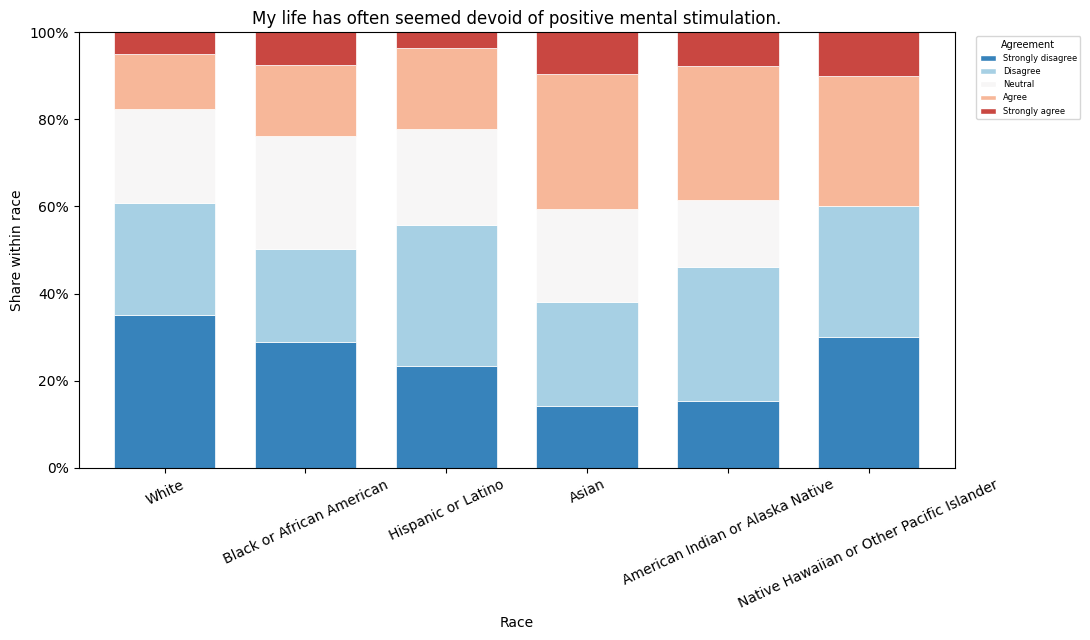

In [145]:
# WELLNESS_30 vs race (within-race distribution, 100% stacked bars)
race_map = {
    1: "White",
    2: "Black or African American",
    3: "Hispanic or Latino",
    4: "Asian",
    5: "American Indian or Alaska Native",
    6: "Native Hawaiian or Other Pacific Islander",
}

# 5-point agreement (edit if your codebook differs)
wellness30_labels = {
    1: "Strongly disagree",
    2: "Disagree",
    3: "Neutral",
    4: "Agree",
    5: "Strongly agree",
}

title_q = "My life has often seemed devoid of positive mental stimulation."

race_order = [race_map[k] for k in sorted(race_map.keys())]
order = sorted(wellness30_labels.keys())

sub = df[["RACE", "WELLNESS_30"]].copy()
sub["RACE"] = pd.to_numeric(sub["RACE"], errors="coerce")
sub["WELLNESS_30"] = pd.to_numeric(sub["WELLNESS_30"], errors="coerce")
sub = sub.dropna(subset=["RACE", "WELLNESS_30"])
sub = sub[sub["RACE"].isin(race_map.keys())].copy()
sub["RACE_LABEL"] = sub["RACE"].astype(int).map(race_map)

ct = pd.crosstab(sub["RACE_LABEL"], sub["WELLNESS_30"])
ct = ct.reindex(index=race_order, fill_value=0)
ct = ct.reindex(columns=order, fill_value=0)
prop = ct.div(ct.sum(axis=1).replace(0, float("nan")), axis=0).fillna(0)
prop.columns = [wellness30_labels[c] for c in prop.columns]

fig, ax = plt.subplots(figsize=(11, 6.5))
colors = sns.color_palette("RdBu_r", n_colors=len(prop.columns))
prop.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=colors,
    width=0.72,
    edgecolor="white",
    linewidth=0.5,
    legend=False,
)
ax.set_ylim(0, 1)
ax.set_ylabel("Share within race")
ax.set_xlabel("Race")
ax.set_title(title_q)
ax.tick_params(axis="x", rotation=25)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
handles = [
    plt.Rectangle((0, 0), 1, 1, facecolor=colors[i], edgecolor="white")
    for i in range(len(prop.columns))
]
ax.legend(
    handles,
    list(prop.columns),
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    fontsize=6,
    title="Agreement",
    title_fontsize=7,
)
plt.tight_layout()
plt.show()


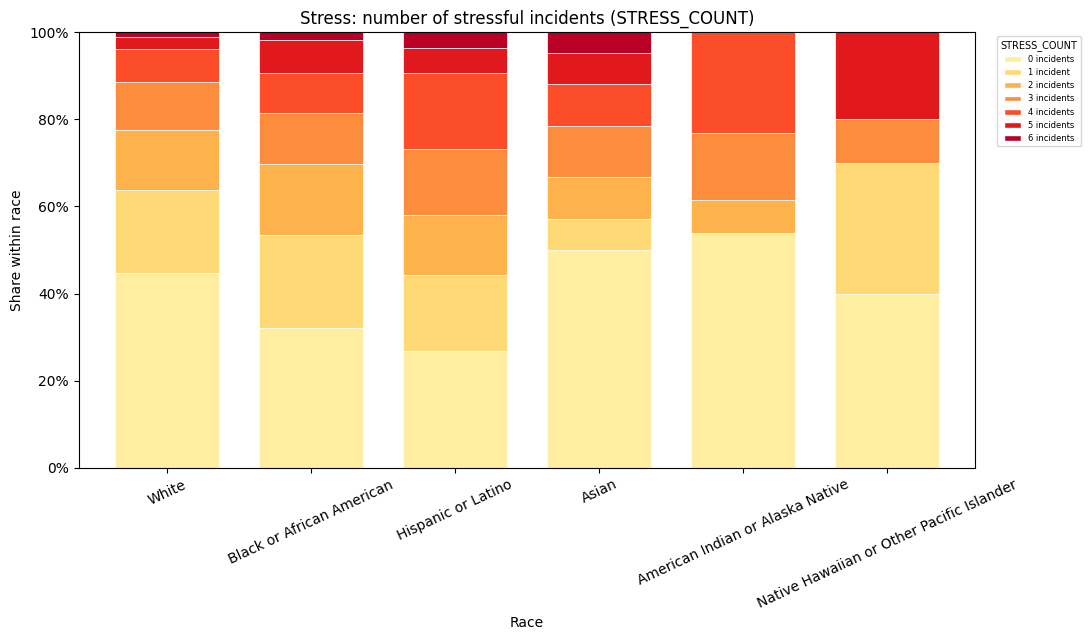

In [146]:
# STRESS_COUNT vs race (within-race distribution of incident counts, 100% stacked bars)
race_map = {
    1: "White",
    2: "Black or African American",
    3: "Hispanic or Latino",
    4: "Asian",
    5: "American Indian or Alaska Native",
    6: "Native Hawaiian or Other Pacific Islander",
}

# STRESS_COUNT is 0–6 in this dataset
stress_count_labels = {
    0: "0 incidents",
    1: "1 incident",
    2: "2 incidents",
    3: "3 incidents",
    4: "4 incidents",
    5: "5 incidents",
    6: "6 incidents",
}

title_q = "Stress: number of stressful incidents (STRESS_COUNT)"

race_order = [race_map[k] for k in sorted(race_map.keys())]
order = sorted(stress_count_labels.keys())

sub = df[["RACE", "STRESS_COUNT"]].copy()
sub["RACE"] = pd.to_numeric(sub["RACE"], errors="coerce")
sub["STRESS_COUNT"] = pd.to_numeric(sub["STRESS_COUNT"], errors="coerce")
sub = sub.dropna(subset=["RACE", "STRESS_COUNT"])
sub = sub[sub["RACE"].isin(race_map.keys())].copy()
sub["RACE_LABEL"] = sub["RACE"].astype(int).map(race_map)

ct = pd.crosstab(sub["RACE_LABEL"], sub["STRESS_COUNT"])
ct = ct.reindex(index=race_order, fill_value=0)
ct = ct.reindex(columns=order, fill_value=0)
prop = ct.div(ct.sum(axis=1).replace(0, float("nan")), axis=0).fillna(0)
prop.columns = [stress_count_labels[c] for c in prop.columns]

fig, ax = plt.subplots(figsize=(11, 6.5))
colors = sns.color_palette("YlOrRd", n_colors=len(prop.columns))
prop.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=colors,
    width=0.72,
    edgecolor="white",
    linewidth=0.5,
    legend=False,
)
ax.set_ylim(0, 1)
ax.set_ylabel("Share within race")
ax.set_xlabel("Race")
ax.set_title(title_q)
ax.tick_params(axis="x", rotation=25)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
handles = [
    plt.Rectangle((0, 0), 1, 1, facecolor=colors[i], edgecolor="white")
    for i in range(len(prop.columns))
]
ax.legend(
    handles,
    list(prop.columns),
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    fontsize=6,
    title="STRESS_COUNT",
    title_fontsize=7,
)
plt.tight_layout()
plt.show()


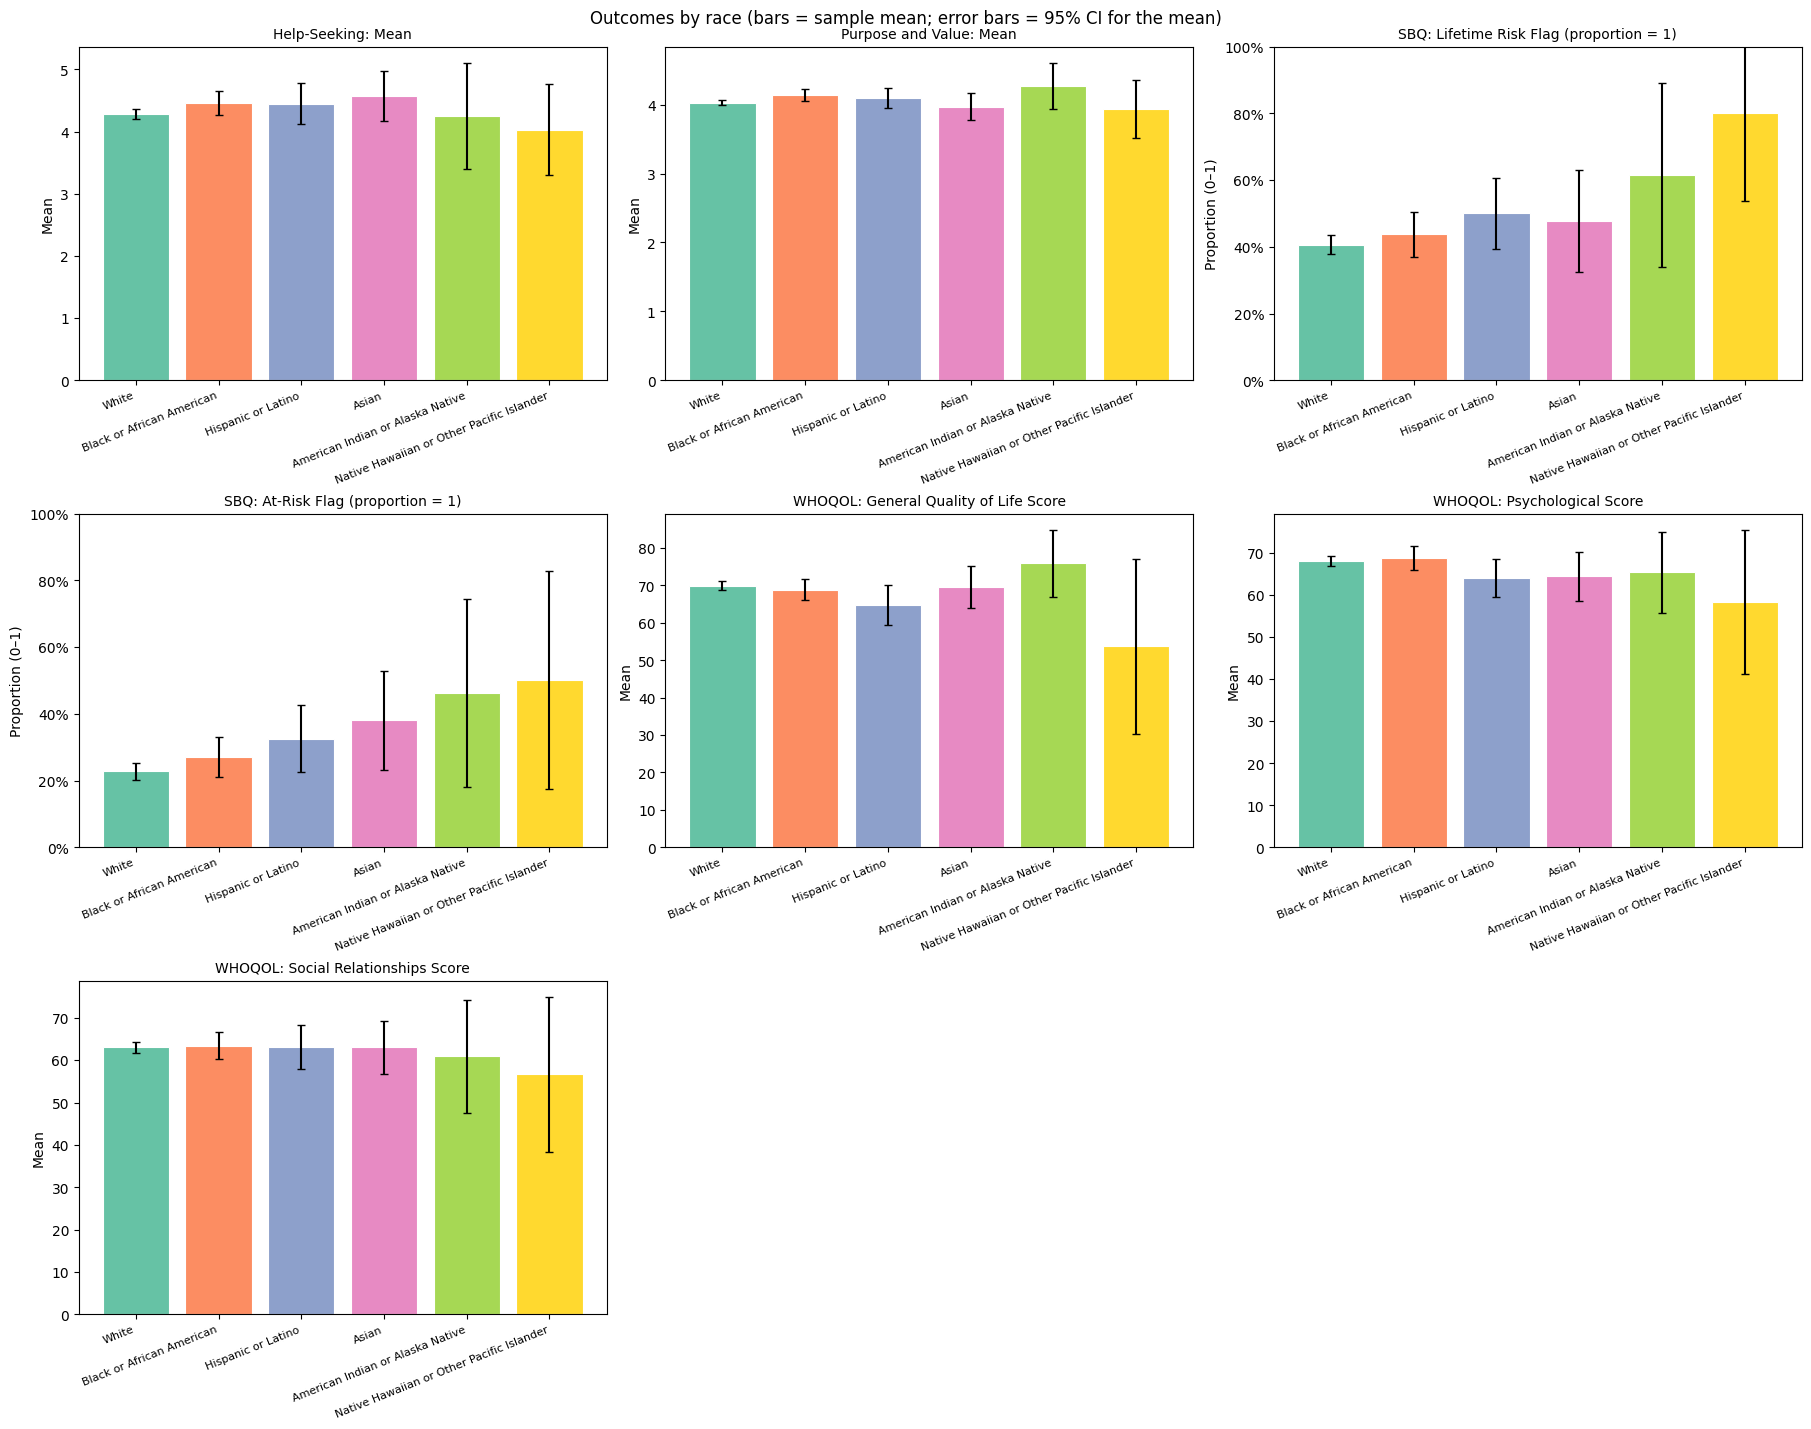

In [147]:
# HS_MEAN, PUR_MEAN, SBQ_*, QOL, PSY, SOCREL — mean (or proportion) by race
import textwrap
import numpy as np

race_map = {
    1: "White",
    2: "Black or African American",
    3: "Hispanic or Latino",
    4: "Asian",
    5: "American Indian or Alaska Native",
    6: "Native Hawaiian or Other Pacific Islander",
}

VAR_SPECS = [
    ("HS_MEAN", "Help-Seeking: Mean"),
    ("PUR_MEAN", "Purpose and Value: Mean"),
    ("SBQ_LIFE", "SBQ: Lifetime Risk Flag (proportion = 1)"),
    ("SBQ_FLAG", "SBQ: At-Risk Flag (proportion = 1)"),
    ("QOL", "WHOQOL: General Quality of Life Score"),
    ("PSY", "WHOQOL: Psychological Score"),
    ("SOCREL", "WHOQOL: Social Relationships Score"),
]

race_order = [race_map[k] for k in sorted(race_map.keys())]
flag_cols = {"SBQ_LIFE", "SBQ_FLAG"}

cols_needed = ["RACE"] + [c for c, _ in VAR_SPECS]
plot_df = df[cols_needed].copy()
plot_df["RACE"] = pd.to_numeric(plot_df["RACE"], errors="coerce")
for c, _ in VAR_SPECS:
    plot_df[c] = pd.to_numeric(plot_df[c], errors="coerce")
plot_df = plot_df.dropna(subset=["RACE"])
plot_df = plot_df[plot_df["RACE"].isin(race_map.keys())].copy()
plot_df["RACE_LABEL"] = plot_df["RACE"].astype(int).map(race_map)

fig, axes = plt.subplots(3, 3, figsize=(18, 14), constrained_layout=True)
axes_flat = axes.flatten()
colors = sns.color_palette("Set2", n_colors=len(race_order))

for i, (col, title) in enumerate(VAR_SPECS):
    ax = axes_flat[i]
    sub = plot_df.dropna(subset=[col])
    if sub.empty:
        ax.set_visible(False)
        continue
    stats = (
        sub.groupby("RACE_LABEL", observed=True)[col]
        .agg(mean="mean", n="count", std="std")
        .reindex(race_order)
    )
    means = stats["mean"].to_numpy()
    se = stats["std"].to_numpy() / np.sqrt(stats["n"].to_numpy())
    ci = np.nan_to_num(1.96 * se, nan=0.0)
    x = np.arange(len(race_order))
    ax.bar(x, means, yerr=ci, capsize=3, color=colors, edgecolor="white", linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(race_order, rotation=22, ha="right", fontsize=8)
    ax.set_title("\\n".join(textwrap.wrap(title, width=42)), fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel("Mean" if col not in flag_cols else "Proportion (0–1)")
    if col in flag_cols:
        ax.set_ylim(0, 1)
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))

for j in range(len(VAR_SPECS), len(axes_flat)):
    axes_flat[j].set_visible(False)

fig.suptitle(
    "Outcomes by race (bars = sample mean; error bars = 95% CI for the mean)",
    fontsize=12,
    y=1.01,
)
plt.show()


While help-seeking behavior and sense of purpose are relatively consistent across racial groups, substantial disparities emerge in suicide risk indicators. American Indian / Alaska Native and Native Hawaiian / Pacific Islander respondents show notably higher proportions of lifetime and current suicide risk, although estimates for these groups carry greater uncertainty due to smaller sample sizes. Differences in quality of life are present but less pronounced, with some evidence of lower psychological well-being among certain groups. Overall, these findings suggest that disparities in mental health outcomes are not driven by differences in help-seeking, but may instead reflect differences in lived experience or stress burden.

Sample n = 882 

OLS: SBQ_TOTAL ~ stress_index * race (interaction = difference in slopes vs White)
                            OLS Regression Results                            
Dep. Variable:              SBQ_TOTAL   R-squared:                       0.126
Model:                            OLS   Adj. R-squared:                  0.115
Method:                 Least Squares   F-statistic:                     11.38
Date:                Mon, 20 Apr 2026   Prob (F-statistic):           5.59e-20
Time:                        09:46:53   Log-Likelihood:                -2434.3
No. Observations:                 882   AIC:                             4893.
Df Residuals:                     870   BIC:                             4950.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                                                                                                            co

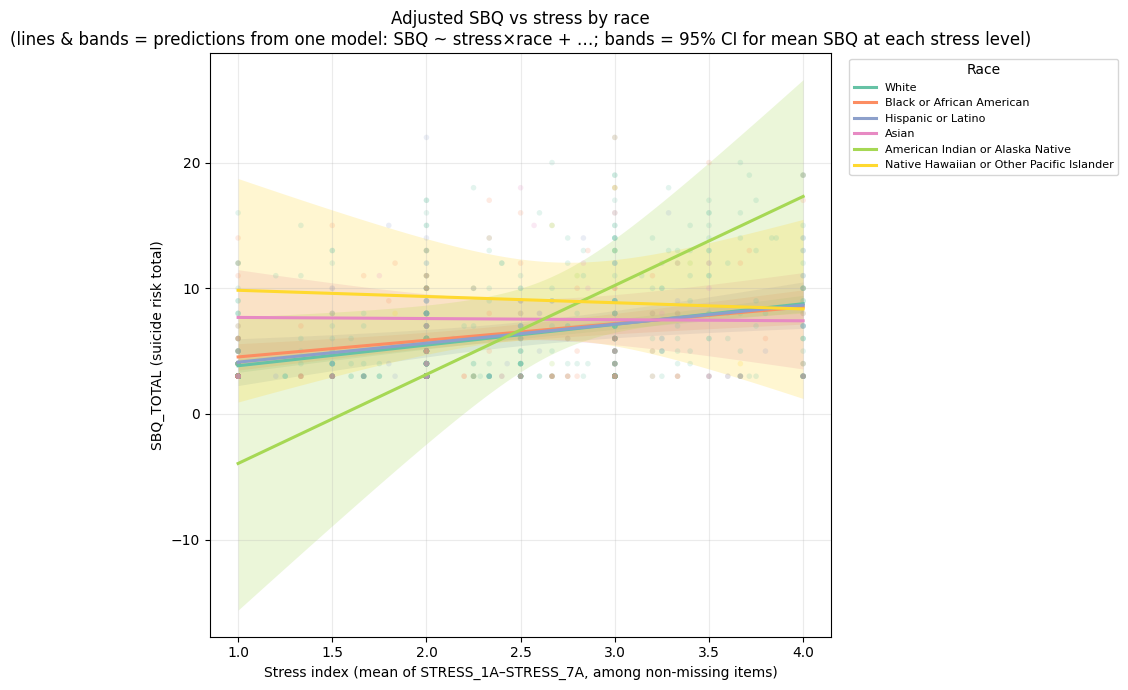

In [148]:
# Combined model: SBQ ~ stress + race + stress×race
# Adjusted prediction lines + slope CIs from ONE fit (statsmodels)
import numpy as np
from scipy import stats

try:
    import statsmodels.formula.api as smf
    from statsmodels.stats.anova import anova_lm
except ImportError as e:
    raise ImportError("pip install statsmodels") from e

race_map = {
    1: "White",
    2: "Black or African American",
    3: "Hispanic or Latino",
    4: "Asian",
    5: "American Indian or Alaska Native",
    6: "Native Hawaiian or Other Pacific Islander",
}
race_order = [race_map[k] for k in sorted(race_map.keys())]
REF = "White"

stress_a_cols = [f"STRESS_{i}A" for i in range(1, 8)]
cols = ["RACE", "SBQ_TOTAL"] + stress_a_cols
reg_df = df[cols].copy()
reg_df["RACE"] = pd.to_numeric(reg_df["RACE"], errors="coerce")
reg_df["SBQ_TOTAL"] = pd.to_numeric(reg_df["SBQ_TOTAL"], errors="coerce")
for c in stress_a_cols:
    reg_df[c] = pd.to_numeric(reg_df[c], errors="coerce")
reg_df["stress_index"] = reg_df[stress_a_cols].mean(axis=1, skipna=True)
reg_df = reg_df.dropna(subset=["RACE", "SBQ_TOTAL", "stress_index"])
reg_df = reg_df[reg_df["RACE"].isin(race_map.keys())].copy()
reg_df["RACE_LABEL"] = reg_df["RACE"].astype(int).map(race_map)

formula = (
    "SBQ_TOTAL ~ stress_index * C(RACE_LABEL, Treatment(reference='White'))"
)
m = smf.ols(formula, data=reg_df).fit()
print("Sample n =", len(reg_df), "\n")
print("=" * 72)
print("OLS: SBQ_TOTAL ~ stress_index * race (interaction = difference in slopes vs White)")
print("=" * 72)
print(m.summary())
print()
print(anova_lm(m, typ=2))
print()
m_add = smf.ols(
    "SBQ_TOTAL ~ stress_index + C(RACE_LABEL, Treatment(reference='White'))",
    data=reg_df,
).fit()
lr, p_lr, dof = m.compare_lr_test(m_add)
print(
    f"LR test, interaction terms all zero: "
    f"chisq({dof:.0f}) = {lr:.3f}, p = {p_lr:.4g}"
)
print()


# --- Slopes + 95% CI (per race), from the combined model ---
p = m.params
V = m.cov_params()
t_crit = float(stats.t.ppf(0.975, m.df_resid))
base = "stress_index"

def slope_and_se_for_race(race: str):
    if race == REF:
        se = np.sqrt(V.loc[base, base])
        return p[base], se
    suffix = f"[T.{race}]"
    hits = [
        n for n in p.index
        if n.startswith("stress_index:") and "RACE_LABEL" in n and n.endswith(suffix)
    ]
    if len(hits) != 1:
        raise ValueError(f"Could not match slope for {race!r}: {hits}")
    k = hits[0]
    sl = p[base] + p[k]
    var = (
        V.loc[base, base]
        + V.loc[k, k]
        + 2 * V.loc[base, k]
    )
    return sl, np.sqrt(var)


print("Predicted SBQ–stress slopes by race (from combined model; ref = White)")
print("-" * 72)
rows = []
for race in race_order:
    sl, se = slope_and_se_for_race(race)
    lo, hi = sl - t_crit * se, sl + t_crit * se
    rows.append({"race": race, "slope": sl, "se": se, "ci_low": lo, "ci_high": hi})
    print(
        f"{race[:44]:44s}  slope={sl:7.4f}  SE={se:.4f}  "
        f"95% CI [{lo:6.3f}, {hi:6.3f}]"
    )
print("-" * 72)
print()

# --- Adjusted mean lines + simultaneous confidence bands for E[SBQ|x,race] ---
grid = np.linspace(reg_df["stress_index"].min(), reg_df["stress_index"].max(), 100)
fig, ax = plt.subplots(figsize=(10, 7))
pal = dict(zip(race_order, sns.color_palette("Set2", n_colors=len(race_order))))

for race in race_order:
    pred_df = pd.DataFrame({"stress_index": grid, "RACE_LABEL": race})
    sf = m.get_prediction(pred_df).summary_frame(alpha=0.05)
    c = pal[race]
    ax.fill_between(
        grid,
        sf["mean_ci_lower"],
        sf["mean_ci_upper"],
        color=c,
        alpha=0.22,
        linewidth=0,
    )
    ax.plot(grid, sf["mean"], color=c, linewidth=2.2, label=race)

for race in race_order:
    sub = reg_df[reg_df["RACE_LABEL"] == race]
    ax.scatter(
        sub["stress_index"],
        sub["SBQ_TOTAL"],
        color=pal[race],
        alpha=0.18,
        s=16,
        edgecolors="none",
    )

ax.set_xlabel("Stress index (mean of STRESS_1A–STRESS_7A, among non-missing items)")
ax.set_ylabel("SBQ_TOTAL (suicide risk total)")
ax.set_title(
    "Adjusted SBQ vs stress by race\n"
    "(lines & bands = predictions from one model: SBQ ~ stress×race + …; "
    "bands = 95% CI for mean SBQ at each stress level)"
)
ax.legend(title="Race", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
ax.grid(axis="both", alpha=0.25)
plt.tight_layout()
plt.show()


Stress is a strong and consistent predictor of suicide risk across racial groups. Once stress is accounted for, racial differences in suicide risk are largely attenuated and no longer statistically significant. Additionally, the relationship between stress and suicide risk appears similar across most groups, suggesting that disparities are not driven by differences in sensitivity to stress. While there is some evidence that stress may have a stronger effect among American Indian or Alaska Native respondents, this estimate is highly uncertain due to small sample size. Overall, these findings indicate that differences in suicide risk are better explained by variation in stress exposure rather than race itself.

The relationship between stress and suicide risk is broadly consistent across racial groups, with similar positive associations observed among White, Black, and Hispanic respondents. However, differences in baseline levels of suicide risk suggest that disparities are not driven by differential sensitivity to stress, but rather by underlying differences in vulnerability. These findings indicate that even at comparable levels of stress, certain groups may experience higher overall risk, pointing to structural or contextual factors beyond stress exposure itself.

In [149]:
# Racial gaps in SBQ before vs after controlling for stress (additive model only)
# For the full interaction model (slopes differ by race), see the previous cell.
# Does stress intensity explain racial differences in suicide risk?
# Compare SBQ ~ race (unadjusted) vs SBQ ~ race + stress (adjusted for stress intensity)
import numpy as np

try:
    import statsmodels.formula.api as smf
    from statsmodels.stats.anova import anova_lm
except ImportError as e:
    raise ImportError(
        "Install statsmodels in this environment: pip install statsmodels"
    ) from e

race_map = {
    1: "White",
    2: "Black or African American",
    3: "Hispanic or Latino",
    4: "Asian",
    5: "American Indian or Alaska Native",
    6: "Native Hawaiian or Other Pacific Islander",
}
race_order = [race_map[k] for k in sorted(race_map.keys())]

stress_a_cols = [f"STRESS_{i}A" for i in range(1, 8)]
cols = ["RACE", "SBQ_TOTAL"] + stress_a_cols
reg_df = df[cols].copy()
reg_df["RACE"] = pd.to_numeric(reg_df["RACE"], errors="coerce")
reg_df["SBQ_TOTAL"] = pd.to_numeric(reg_df["SBQ_TOTAL"], errors="coerce")
for c in stress_a_cols:
    reg_df[c] = pd.to_numeric(reg_df[c], errors="coerce")
reg_df["stress_index"] = reg_df[stress_a_cols].mean(axis=1, skipna=True)
reg_df = reg_df.dropna(subset=["RACE", "SBQ_TOTAL", "stress_index"])
reg_df = reg_df[reg_df["RACE"].isin(race_map.keys())].copy()
reg_df["RACE_LABEL"] = reg_df["RACE"].astype(int).map(race_map)

print("Reference group for race: White")
print("Sample n =", len(reg_df), "(same as stress-index analysis: ≥1 stressfulness rating)\n")

# --- Unadjusted: mean SBQ by race ---
print("=" * 72)
print("1) UNADJUSTED: mean SBQ_TOTAL by race (descriptive)")
print("=" * 72)
desc = (
    reg_df.groupby("RACE_LABEL", observed=True)["SBQ_TOTAL"]
    .agg(["mean", "std", "count"])
    .reindex(race_order)
)
desc["mean"] = desc["mean"].round(2)
desc["std"] = desc["std"].round(2)
print(desc.to_string())
print()

# OLS: SBQ ~ race only (coefficients = difference vs White)
m_unadj = smf.ols(
    "SBQ_TOTAL ~ C(RACE_LABEL, Treatment(reference='White'))",
    data=reg_df,
).fit()
print("OLS (unadjusted): SBQ_TOTAL ~ race")
print(f"  R² = {m_unadj.rsquared:.4f}")
print(anova_lm(m_unadj, typ=2).to_string())
print()
print("Coefficients (difference vs White):")
print(m_unadj.params.round(4).to_string())
print()

# OLS: SBQ ~ race + stress
m_adj = smf.ols(
    "SBQ_TOTAL ~ C(RACE_LABEL, Treatment(reference='White')) + stress_index",
    data=reg_df,
).fit()
print("=" * 72)
print("2) ADJUSTED: same model + stress_index (mean of STRESS_1A–STRESS_7A)")
print("=" * 72)
print(f"  R² = {m_adj.rsquared:.4f}")
print(anova_lm(m_adj, typ=2).to_string())
print()
print("Coefficients (difference vs White, controlling for stress_index):")
print(m_adj.params.round(4).to_string())
print()

# Side-by-side race contrasts
print("=" * 72)
print("3) SUMMARY: race contrasts vs White — before vs after controlling for stress")
print("=" * 72)
coef_u = m_unadj.params.drop("Intercept")
coef_a = m_adj.params.drop(["Intercept", "stress_index"])
common = coef_u.index.intersection(coef_a.index)
comp = pd.DataFrame({
    "coef_unadjusted": coef_u.loc[common],
    "coef_adjusted": coef_a.loc[common],
    "change": coef_a.loc[common] - coef_u.loc[common],
})
print(comp.round(4).to_string())
print()
print(
    "Interpretation: If stress explains racial gaps in SBQ, race coefficients "
    "should move toward 0 after adding stress_index (compare 'change' column). "
    "Use Type II ANOVA F/p for C(RACE_LABEL) above to see whether race remains "
    "significant after adjustment."
)


Reference group for race: White
Sample n = 882 (same as stress-index analysis: ≥1 stressfulness rating)

1) UNADJUSTED: mean SBQ_TOTAL by race (descriptive)
                                           mean   std  count
RACE_LABEL                                                  
White                                      5.91  3.96    636
Black or African American                  6.17  4.31    149
Hispanic or Latino                         6.40  4.49     63
Asian                                      7.55  4.19     22
American Indian or Alaska Native           8.00  4.47      6
Native Hawaiian or Other Pacific Islander  9.00  6.13      6

OLS (unadjusted): SBQ_TOTAL ~ race
  R² = 0.0100
                                                   sum_sq     df         F    PR(>F)
C(RACE_LABEL, Treatment(reference='White'))    147.233674    5.0  1.767005  0.117065
Residual                                     14598.336620  876.0       NaN       NaN

Coefficients (difference vs White):
Intercept    

Although descriptive statistics suggest higher average suicide risk among some racial groups, these differences are not statistically significant when considered in isolation. Race explains only a small proportion of variance in suicide risk. This suggests that observed disparities may be driven by other factors—most notably stress—rather than race itself.

In [150]:
try:
    import statsmodels.formula.api as smf
    from statsmodels.stats.anova import anova_lm
except ImportError as e:
    raise ImportError("pip install statsmodels") from e

import numpy as np
import pandas as pd

race_map = {
    1: "White",
    2: "Black or African American",
    3: "Hispanic or Latino",
    4: "Asian",
    5: "American Indian or Alaska Native",
    6: "Native Hawaiian or Other Pacific Islander",
}
race_order = [race_map[k] for k in sorted(race_map.keys())]
REF = "White"

stress_yes = [f"STRESS_{i}" for i in range(1, 8)]
stress_a_cols = [f"STRESS_{i}A" for i in range(1, 8)]

cols = ["RACE", "SBQ_TOTAL"] + stress_yes + stress_a_cols
if "STRESS_SUM" in df.columns:
    cols.append("STRESS_SUM")

exp = df[cols].copy()

# numeric coercion
for c in exp.columns:
    exp[c] = pd.to_numeric(exp[c], errors="coerce")

# only require race + SBQ at the base stage
exp = exp.dropna(subset=["RACE", "SBQ_TOTAL"])
exp = exp[exp["RACE"].isin(race_map.keys())].copy()
exp["RACE_LABEL"] = exp["RACE"].astype(int).map(race_map)

# ---- IMPORTANT: verify coding of STRESS_i ----
# If "yes" is coded as 1, this is correct.
# If your data uses 2 for yes, change (exp[stress_yes] == 1) accordingly.
exp["n_stressors"] = (exp[stress_yes] == 1).sum(axis=1)

# mean stressfulness among available STRESS_iA items
exp["stress_index"] = exp[stress_a_cols].mean(axis=1, skipna=True)

# product burden: 0 if no endorsed stressors, else count * mean intensity
exp["burden_product"] = np.where(
    exp["n_stressors"] == 0,
    0.0,
    exp["n_stressors"] * exp["stress_index"]
)

# optional: compute a replacement stress sum directly from item intensities
# This is often better than relying on a sparse STRESS_SUM column.
exp["stress_sum_from_items"] = exp[stress_a_cols].fillna(0).sum(axis=1)

print("Base N (race + SBQ only) =", len(exp))
if "STRESS_SUM" in exp.columns:
    print("Non-missing STRESS_SUM =", exp["STRESS_SUM"].notna().sum())
print("Non-missing burden_product =", exp["burden_product"].notna().sum())
print("Non-missing stress_sum_from_items =", exp["stress_sum_from_items"].notna().sum())
print()

# quick sanity checks
for c in stress_yes:
    print(c, exp[c].value_counts(dropna=False).sort_index().to_dict())
print()

def run_three_tests(d, burden_col: str, title: str):
    d = d.dropna(subset=[burden_col, "SBQ_TOTAL", "RACE_LABEL"]).copy()

    print("\n" + "=" * 72)
    print(title)
    print("=" * 72)
    print("N =", len(d))

    print(f"\n(1) Exposure test: does {burden_col} differ by race?\n")
    m1 = smf.ols(
        f"{burden_col} ~ C(RACE_LABEL, Treatment(reference='{REF}'))",
        data=d,
    ).fit()
    print(anova_lm(m1, typ=2))
    print(f"R² = {m1.rsquared:.4f}")

    print(f"\nDescriptive means for {burden_col} by race\n")
    print(
        d.groupby("RACE_LABEL", observed=True)[burden_col]
        .agg(["mean", "std", "count"])
        .reindex(race_order)
    )

    print(f"\n(2) Prediction: does {burden_col} predict SBQ?\n")
    m2 = smf.ols(f"SBQ_TOTAL ~ {burden_col}", data=d).fit()
    print(m2.summary().tables[1])
    print(f"R² = {m2.rsquared:.4f}")

    print(
        f"\n(3) Mediation-style: does {burden_col} explain racial gaps in SBQ?\n"
        f"    Compare SBQ ~ race  vs  SBQ ~ {burden_col} + race\n"
    )
    m0 = smf.ols(
        f"SBQ_TOTAL ~ C(RACE_LABEL, Treatment(reference='{REF}'))",
        data=d,
    ).fit()
    m3 = smf.ols(
        f"SBQ_TOTAL ~ {burden_col} + C(RACE_LABEL, Treatment(reference='{REF}'))",
        data=d,
    ).fit()

    print("--- SBQ ~ race only ---")
    print(f"R² = {m0.rsquared:.4f}")
    print(anova_lm(m0, typ=2))

    print(f"\n--- SBQ ~ {burden_col} + race ---")
    print(f"R² = {m3.rsquared:.4f}")
    print(anova_lm(m3, typ=2))

    c0 = m0.params.drop("Intercept", errors="ignore")
    c3 = m3.params.drop(["Intercept", burden_col], errors="ignore")
    common = c0.index.intersection(c3.index)

    tab = pd.DataFrame({
        "coef_race_only": c0.loc[common],
        "coef_adj_burden": c3.loc[common],
    })
    tab["change"] = tab["coef_adj_burden"] - tab["coef_race_only"]

    print("\nRace coefficients vs White:")
    print(tab.round(4).to_string())

# Only run this if STRESS_SUM has usable coverage
if "STRESS_SUM" in exp.columns and exp["STRESS_SUM"].notna().sum() >= 50:
    run_three_tests(
        exp.dropna(subset=["STRESS_SUM"]).copy(),
        "STRESS_SUM",
        "PRIMARY: burden = STRESS_SUM"
    )
else:
    print("Skipping STRESS_SUM analysis because STRESS_SUM is too sparse.\n")

run_three_tests(
    exp,
    "burden_product",
    "PRIMARY: burden = (# endorsed stressors) × mean stressfulness; 0 if none"
)

run_three_tests(
    exp,
    "stress_sum_from_items",
    "ALTERNATE: burden = sum of STRESS_1A ... STRESS_7A with missing filled as 0"
)

Base N (race + SBQ only) = 1469
Non-missing STRESS_SUM = 18
Non-missing burden_product = 1469
Non-missing stress_sum_from_items = 1469

STRESS_1 {0: 1171, 1: 298}
STRESS_2 {0: 969, 1: 500}
STRESS_3 {0: 1197, 1: 272}
STRESS_4 {0: 1060, 1: 409}
STRESS_5 {0: 1097, 1: 372}
STRESS_6 {0: 1224, 1: 245}
STRESS_7 {0: 1218, 1: 251}

Skipping STRESS_SUM analysis because STRESS_SUM is too sparse.


PRIMARY: burden = (# endorsed stressors) × mean stressfulness; 0 if none
N = 1469

(1) Exposure test: does burden_product differ by race?

                                                   sum_sq      df         F  \
C(RACE_LABEL, Treatment(reference='White'))    935.419813     5.0  6.769888   
Residual                                     40429.597206  1463.0       NaN   

                                               PR(>F)  
C(RACE_LABEL, Treatment(reference='White'))  0.000003  
Residual                                          NaN  
R² = 0.0226

Descriptive means for burden_product by race

      


Suicide risk (higher = greater suicide risk)
Listwise N = 1469

(1) Does race differ on Y?   Y ~ race
R² = 0.0158
                                                   sum_sq      df         F  \
C(RACE_LABEL, Treatment(reference='White'))    318.722953     5.0  4.690902   
Residual                                     19880.682084  1463.0       NaN   

                                               PR(>F)  
C(RACE_LABEL, Treatment(reference='White'))  0.000297  
Residual                                          NaN  

(2) Does burden predict Y?   Y ~ burden_product
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          4.2229      0.112     37.866      0.000       4.004       4.442
burden_product     0.2706      0.017     16.085      0.000       0.238       0.304
R² = 0.1499

(3) Does burden explain racial differences?   Y ~ burden_product + race
R² (adjusted)

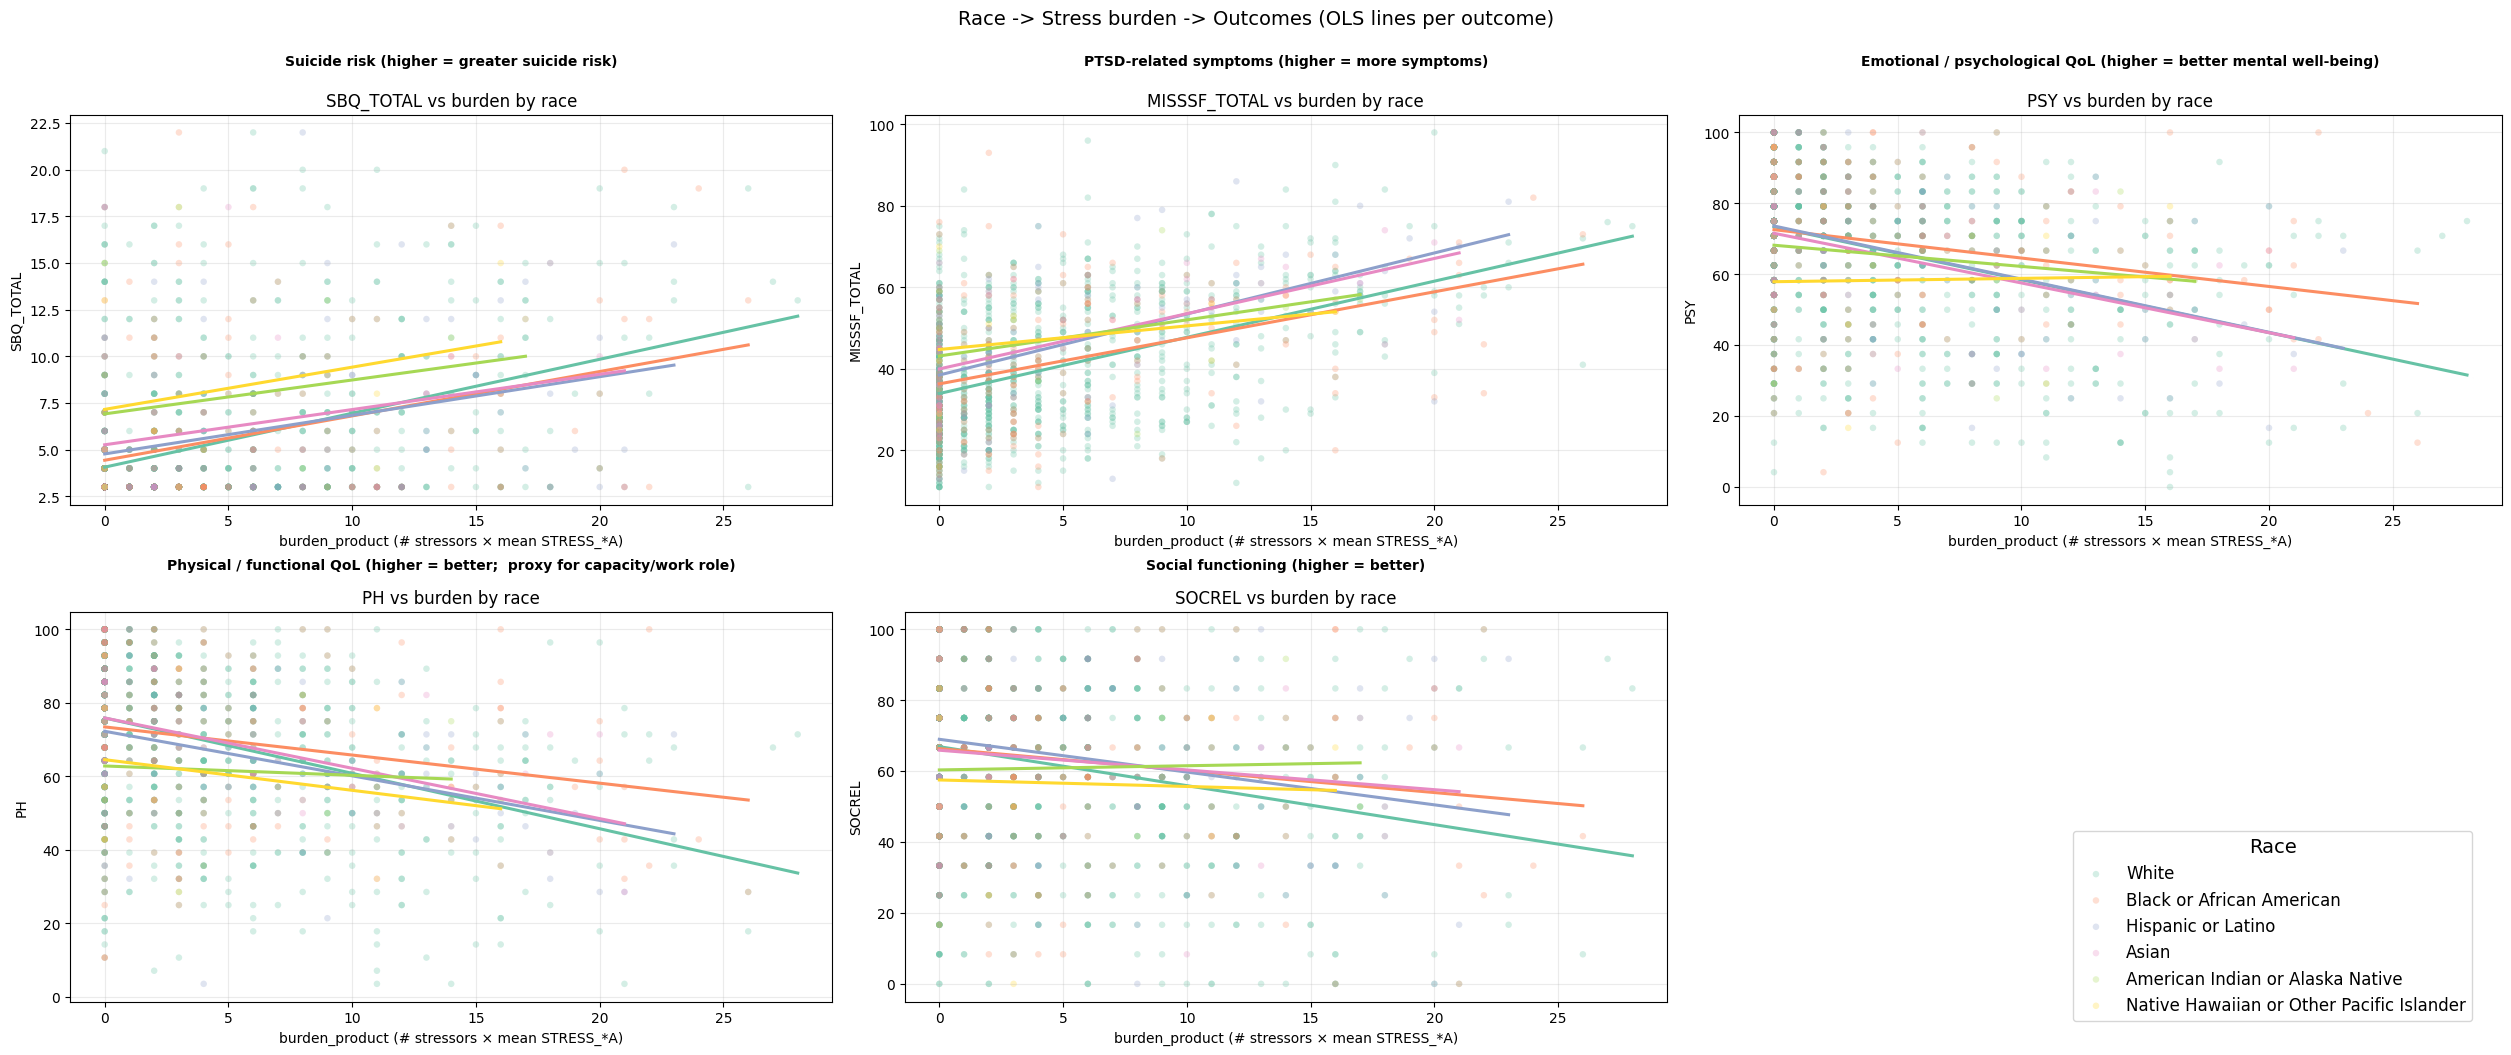

In [159]:
# Race → stress burden → outcomes: regressions + paired figures (per outcome)
# For each Y: (1) Y ~ race  (2) Y ~ burden_product  (3) Y ~ burden + race + coef comparison
try:
    import statsmodels.formula.api as smf
    from statsmodels.stats.anova import anova_lm
except ImportError as e:
    raise ImportError("pip install statsmodels") from e

import numpy as np
import textwrap

race_map = {
    1: "White",
    2: "Black or African American",
    3: "Hispanic or Latino",
    4: "Asian",
    5: "American Indian or Alaska Native",
    6: "Native Hawaiian or Other Pacific Islander",
}
race_order = [race_map[k] for k in sorted(race_map.keys())]
REF = "White"

stress_yes = [f"STRESS_{i}" for i in range(1, 8)]
stress_a_cols = [f"STRESS_{i}A" for i in range(1, 8)]

OUTCOMES = [
    ("SBQ_TOTAL", "Suicide risk (higher = greater suicide risk)"),
    ("MISSSF_TOTAL", "PTSD-related symptoms (higher = more symptoms)"),
    (
        "PSY",
        "Emotional / psychological QoL (higher = better mental well-being)",
    ),
    (
        "PH",
        "Physical / functional QoL (higher = better;\n proxy for capacity/work role)",
    ),
    (
        "SOCREL",
        "Social functioning (higher = better)",
    ),
]

outcome_cols = [c for c, _ in OUTCOMES]
cols = ["RACE"] + stress_yes + stress_a_cols + outcome_cols
wide = df[cols].copy()
wide["RACE"] = pd.to_numeric(wide["RACE"], errors="coerce")
for c in stress_yes + stress_a_cols + outcome_cols:
    wide[c] = pd.to_numeric(wide[c], errors="coerce")

wide["n_stressors"] = (wide[stress_yes] == 1).sum(axis=1)
wide["stress_index"] = wide[stress_a_cols].mean(axis=1, skipna=True)
wide["burden_product"] = np.where(
    wide["n_stressors"].to_numpy() == 0,
    0.0,
    wide["n_stressors"].to_numpy() * wide["stress_index"].to_numpy(),
)

wide = wide.dropna(subset=["RACE", "burden_product"])
wide = wide[wide["RACE"].isin(race_map.keys())].copy()
wide["RACE_LABEL"] = wide["RACE"].astype(int).map(race_map)

pal = sns.color_palette("Set2", n_colors=len(race_order))
color_map = dict(zip(race_order, pal))


def print_three_step_models(data, y: str, y_label: str):
    d = data.dropna(subset=[y, "burden_product"]).copy()
    print("\n" + "=" * 80)
    print(y_label)
    print("=" * 80)
    print(f"Listwise N = {len(d)}")

    print("\n(1) Does race differ on Y?   Y ~ race")
    m_race = smf.ols(
        f"{y} ~ C(RACE_LABEL, Treatment(reference='{REF}'))",
        data=d,
    ).fit()
    print(f"R² = {m_race.rsquared:.4f}")
    print(anova_lm(m_race, typ=2))

    print("\n(2) Does burden predict Y?   Y ~ burden_product")
    m_b = smf.ols(f"{y} ~ burden_product", data=d).fit()
    print(m_b.summary().tables[1])
    print(f"R² = {m_b.rsquared:.4f}")

    print("\n(3) Does burden explain racial differences?   Y ~ burden_product + race")
    m_adj = smf.ols(
        f"{y} ~ burden_product + C(RACE_LABEL, Treatment(reference='{REF}'))",
        data=d,
    ).fit()
    print(f"R² (adjusted) = {m_adj.rsquared:.4f}")
    print(anova_lm(m_adj, typ=2))

    print("\n--- Race coefficients vs White: Y~race only  vs  Y~burden+race ---")
    c0 = m_race.params.drop("Intercept")
    c1 = m_adj.params.drop(["Intercept", "burden_product"])
    common = c0.index.intersection(c1.index)
    tab = pd.DataFrame({"coef_race_only": c0.loc[common], "coef_adj_burden": c1.loc[common]})
    tab["change"] = tab["coef_adj_burden"] - tab["coef_race_only"]
    print(tab.round(4).to_string())
    print(
        "\nNegative change (toward 0) suggests burden accounts for part of the racial gap in Y "
        "(sign depends on scale direction; compare magnitudes)."
    )


def plot_burden_outcome_grid(data, outcomes):
    n_cols = 3
    n_rows = 2
    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(25, 10),
        constrained_layout=True,
    )
    axes = np.asarray(axes).reshape(-1)

    for i, (y, y_label) in enumerate(outcomes):
        d = data.dropna(subset=[y, "burden_product"]).copy()
        ax = axes[i]

        for race in race_order:
            sub = d[d["RACE_LABEL"] == race]
            c = color_map[race]
            ax.scatter(
                sub["burden_product"],
                sub[y],
                color=c,
                alpha=0.28,
                s=22,
                edgecolors="none",
                label=race,
            )
            if len(sub) >= 8:
                coef = np.polyfit(sub["burden_product"], sub[y], 1)
                xg = np.linspace(sub["burden_product"].min(), sub["burden_product"].max(), 80)
                ax.plot(xg, np.poly1d(coef)(xg), color=c, linewidth=2.2)

        ax.set_xlabel("burden_product (# stressors × mean STRESS_*A)")
        ax.set_ylabel(y)
        ax.set_title(f"{y} vs burden by race")
        ax.grid(alpha=0.25)

        row_title = "\n".join(textwrap.wrap(y_label, width=90))
        label_y = 1.10 if i >= n_cols else 1.12
        ax.text(
            0.5,
            label_y,
            row_title,
            transform=ax.transAxes,
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold",
        )

    for ax in axes[len(outcomes):]:
        ax.set_visible(False)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        title="Race",
        loc="lower right",
        bbox_to_anchor=(0.99, 0.02),
        fontsize=12,
        title_fontsize=14,
        frameon=True,
    )

    fig.suptitle(
        "Race -> Stress burden -> Outcomes (OLS lines per outcome)",
        fontsize=14,
        y=1.04,
    )
    plt.show()


for ycol, ylab in OUTCOMES:
    print_three_step_models(wide, ycol, ylab)

plot_burden_outcome_grid(wide, OUTCOMES)


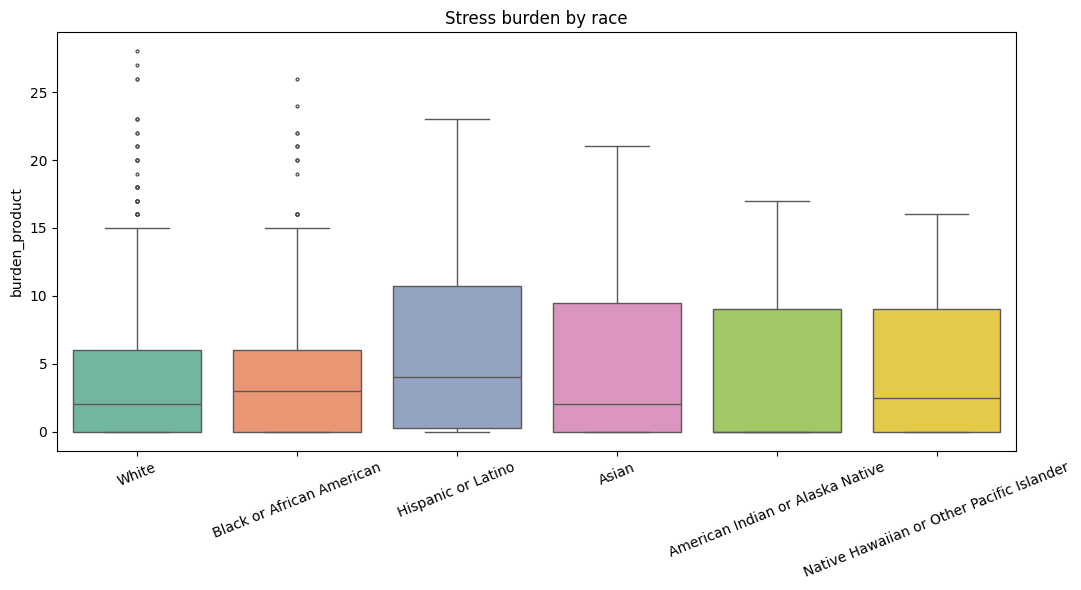

In [152]:
# Separate boxplot: stress burden by race
burden_df = wide.dropna(subset=["burden_product", "RACE_LABEL"]).copy()

plt.figure(figsize=(11, 6))
ax = sns.boxplot(
    data=burden_df,
    x="RACE_LABEL",
    y="burden_product",
    order=race_order,
    hue="RACE_LABEL",
    palette=color_map,
    dodge=False,
    linewidth=1,
    fliersize=2,
)
if ax.get_legend() is not None:
    ax.get_legend().remove()

ax.set_title("Stress burden by race")
ax.set_xlabel("")
ax.set_ylabel("burden_product")
ax.tick_params(axis="x", rotation=22)
plt.tight_layout()
plt.show()

In [153]:
# Combat exposure index (CES items) → stress burden → SBQ: chain models
# CES_1…CES_7 map to patrol / enemy fire / surrounded / KIA rate / fire rounds / witnessing hits / danger.
# Index = mean of z-scored items (equal weight per item). Placed before the written summary.

try:
    import statsmodels.formula.api as smf
    from statsmodels.stats.anova import anova_lm
except ImportError as e:
    raise ImportError("pip install statsmodels") from e

import numpy as np

race_map = {
    1: "White",
    2: "Black or African American",
    3: "Hispanic or Latino",
    4: "Asian",
    5: "American Indian or Alaska Native",
    6: "Native Hawaiian or Other Pacific Islander",
}
REF = "White"
race_order = [race_map[k] for k in sorted(race_map.keys())]

combat_cols = [f"CES_{i}" for i in range(1, 8)]
stress_yes = [f"STRESS_{i}" for i in range(1, 8)]
stress_a_cols = [f"STRESS_{i}A" for i in range(1, 8)]

cols = ["RACE", "SBQ_TOTAL"] + combat_cols + stress_yes + stress_a_cols
chain = df[cols].copy()
chain["RACE"] = pd.to_numeric(chain["RACE"], errors="coerce")
chain["SBQ_TOTAL"] = pd.to_numeric(chain["SBQ_TOTAL"], errors="coerce")
for c in combat_cols + stress_yes + stress_a_cols:
    chain[c] = pd.to_numeric(chain[c], errors="coerce")

z = chain[combat_cols].astype(float).copy()
for c in combat_cols:
    z[c] = (z[c] - z[c].mean()) / z[c].std(ddof=0)
chain["combat_exposure"] = z.mean(axis=1)

chain["n_stressors"] = (chain[stress_yes] == 1).sum(axis=1)
chain["stress_index"] = chain[stress_a_cols].mean(axis=1, skipna=True)
chain["burden_product"] = np.where(
    chain["n_stressors"].to_numpy() == 0,
    0.0,
    chain["n_stressors"].to_numpy() * chain["stress_index"].to_numpy(),
)

chain = chain.dropna(subset=["RACE", "SBQ_TOTAL", "combat_exposure", "burden_product"])
chain = chain[chain["RACE"].isin(race_map.keys())].copy()
chain["RACE_LABEL"] = chain["RACE"].astype(int).map(race_map)

print("=" * 72)
print("Combat exposure: mean of z-scored CES_1 … CES_7")
print("=" * 72)
print(f"Listwise N = {len(chain)}")
print("\nMean combat_exposure by race (higher = more combat vs sample average)")
print(
    chain.groupby("RACE_LABEL")["combat_exposure"]
    .agg(mean="mean", std="std", n="count")
    .reindex(race_order)
    .round(4)
    .to_string()
)

print("\n(1) Does combat exposure differ by race?   combat_exposure ~ race")
m_combat_race = smf.ols(
    f"combat_exposure ~ C(RACE_LABEL, Treatment(reference='{REF}'))",
    data=chain,
).fit()
print(f"R² = {m_combat_race.rsquared:.4f}")
print(anova_lm(m_combat_race, typ=2))

print("\n(2) Does combat predict stress burden?   burden_product ~ combat_exposure")
m_burden_combat = smf.ols("burden_product ~ combat_exposure", data=chain).fit()
print(m_burden_combat.summary().tables[1])
print(f"R² = {m_burden_combat.rsquared:.4f}")

print("\n(3) Full chain on SBQ:  SBQ ~ combat_exposure + burden_product + race")
print("    vs SBQ ~ burden_product + race — check whether combat is incremental and race shrinks.")

m_burden_race = smf.ols(
    f"SBQ_TOTAL ~ burden_product + C(RACE_LABEL, Treatment(reference='{REF}'))",
    data=chain,
).fit()
m_full = smf.ols(
    f"SBQ_TOTAL ~ combat_exposure + burden_product + C(RACE_LABEL, Treatment(reference='{REF}'))",
    data=chain,
).fit()
print(f"R² (burden + race) = {m_burden_race.rsquared:.4f}")
print(f"R² (+ combat)      = {m_full.rsquared:.4f}")
print(m_full.summary().tables[1])
print("\nType II ANOVA (full model):")
print(anova_lm(m_full, typ=2))

c_br = m_burden_race.params.drop(["Intercept", "burden_product"])
c_full = m_full.params.drop(["Intercept", "combat_exposure", "burden_product"])
common = c_br.index.intersection(c_full.index)
comp = pd.DataFrame(
    {
        "coef_burden_race": c_br.loc[common],
        "coef_combat_burden_race": c_full.loc[common],
        "change": c_full.loc[common] - c_br.loc[common],
    }
)
print(
    "\n--- Race vs White: after adding combat to burden+race (negative change → coefficient moves toward 0) ---"
)
print(comp.round(4).to_string())


Combat exposure: mean of z-scored CES_1 … CES_7
Listwise N = 1469

Mean combat_exposure by race (higher = more combat vs sample average)
                                             mean     std     n
RACE_LABEL                                                     
White                                     -0.0691  0.7762  1109
Black or African American                  0.1342  0.9066   211
Hispanic or Latino                         0.2773  0.8748    84
Asian                                      0.2777  0.9218    42
American Indian or Alaska Native           0.7991  1.0858    13
Native Hawaiian or Other Pacific Islander  0.2443  0.7904    10

(1) Does combat exposure differ by race?   combat_exposure ~ race
R² = 0.0281
                                                 sum_sq      df         F  \
C(RACE_LABEL, Treatment(reference='White'))   27.695559     5.0  8.456582   
Residual                                     958.273731  1463.0       NaN   

                                        

Across multiple domains—including suicide risk, PTSD symptoms, psychological well-being, physical functioning, and social relationships—stress burden shows a consistent association with worse outcomes. Importantly, this relationship is similar across racial groups, while levels of stress exposure differ. These findings suggest that disparities across outcomes may be driven by differences in stress exposure rather than differences in vulnerability to stress.

/var/folders/zl/vrkthn715j97ns3mht1gpfm80000gn/T/ipykernel_44234/1668401350.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


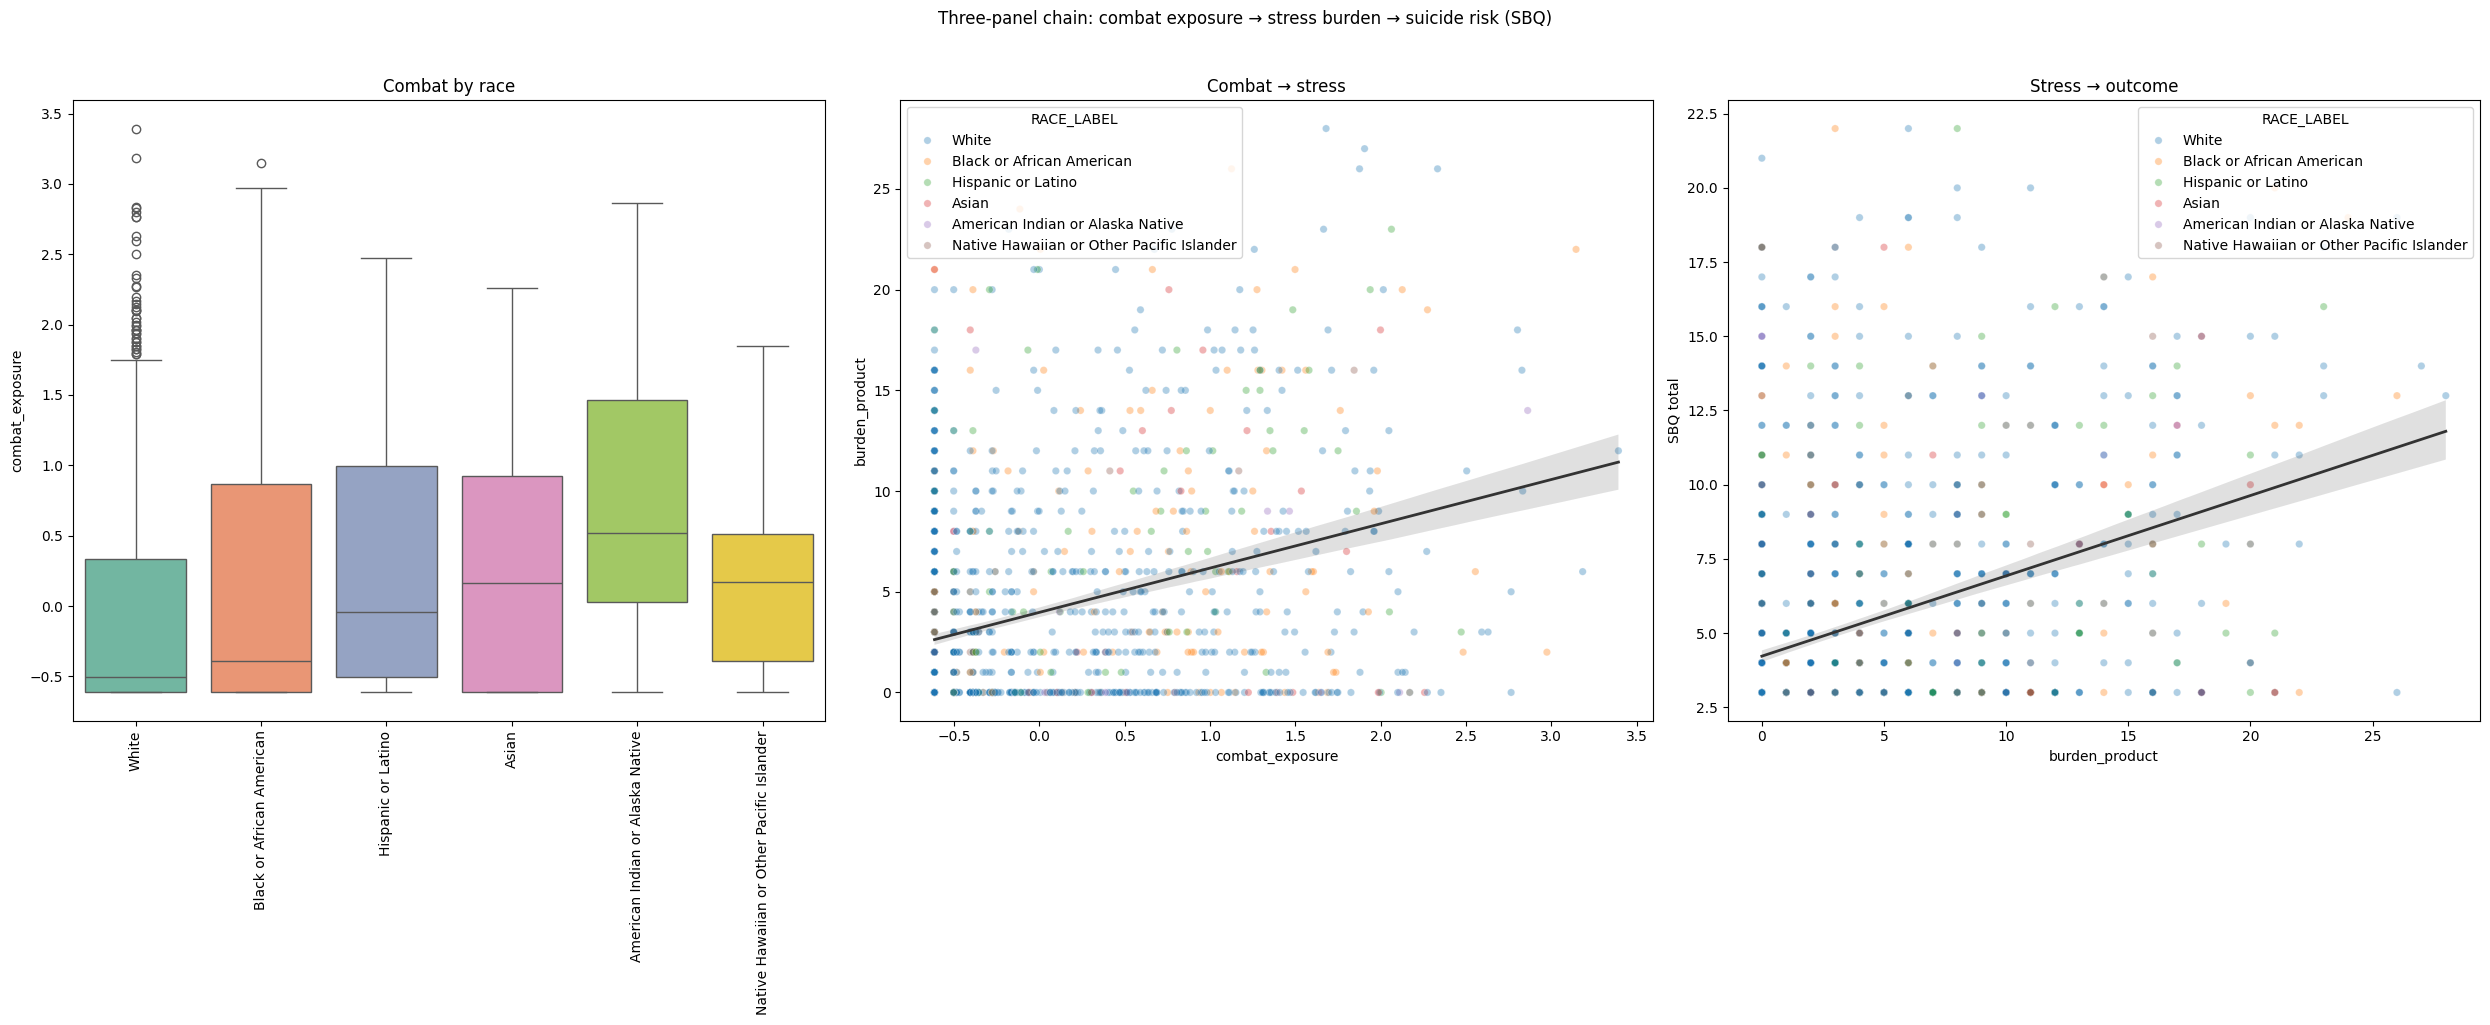

In [167]:
import numpy as np

# Three-panel chain: combat by race → combat–stress → stress–outcome
race_map_plot = {
    1: "White",
    2: "Black or African American",
    3: "Hispanic or Latino",
    4: "Asian",
    5: "American Indian or Alaska Native",
    6: "Native Hawaiian or Other Pacific Islander",
}
race_order_plot = [race_map_plot[k] for k in sorted(race_map_plot.keys())]

combat_cols_plot = [f"CES_{i}" for i in range(1, 8)]
stress_yes_plot = [f"STRESS_{i}" for i in range(1, 8)]
stress_a_plot = [f"STRESS_{i}A" for i in range(1, 8)]

cols_plot = ["RACE", "SBQ_TOTAL"] + combat_cols_plot + stress_yes_plot + stress_a_plot
plot_df = df[cols_plot].copy()
plot_df["RACE"] = pd.to_numeric(plot_df["RACE"], errors="coerce")
plot_df["SBQ_TOTAL"] = pd.to_numeric(plot_df["SBQ_TOTAL"], errors="coerce")
for c in combat_cols_plot + stress_yes_plot + stress_a_plot:
    plot_df[c] = pd.to_numeric(plot_df[c], errors="coerce")

z_ce = plot_df[combat_cols_plot].astype(float).copy()
for c in combat_cols_plot:
    z_ce[c] = (z_ce[c] - z_ce[c].mean()) / z_ce[c].std(ddof=0)
plot_df["combat_exposure"] = z_ce.mean(axis=1)

plot_df["n_stressors"] = (plot_df[stress_yes_plot] == 1).sum(axis=1)
plot_df["stress_index"] = plot_df[stress_a_plot].mean(axis=1, skipna=True)
plot_df["burden_product"] = np.where(
    plot_df["n_stressors"].to_numpy() == 0,
    0.0,
    plot_df["n_stressors"].to_numpy() * plot_df["stress_index"].to_numpy(),
)

plot_df = plot_df.dropna(
    subset=["RACE", "SBQ_TOTAL", "combat_exposure", "burden_product"]
)
plot_df = plot_df[plot_df["RACE"].isin(race_map_plot.keys())].copy()
plot_df["RACE_LABEL"] = plot_df["RACE"].astype(int).map(race_map_plot)

pal_plot = sns.color_palette("Set2", n_colors=len(race_order_plot))

fig, axes = plt.subplots(1, 3, figsize=(25, 10))

# 1. Combat by race (boxplot)
sns.boxplot(
    data=plot_df,
    x="RACE_LABEL",
    y="combat_exposure",
    order=race_order_plot,
    ax=axes[0],
    palette=pal_plot,
)
axes[0].set_title("Combat by race")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=90)

# 2. Combat → stress (scatter + line)
sns.scatterplot(
    data=plot_df,
    x="combat_exposure",
    y="burden_product",
    hue="RACE_LABEL",
    hue_order=race_order_plot,
    ax=axes[1],
    alpha=0.35,
    s=28,
)
sns.regplot(
    data=plot_df,
    x="combat_exposure",
    y="burden_product",
    scatter=False,
    ax=axes[1],
    color="0.2",
    line_kws={"linewidth": 2},
)
axes[1].set_title("Combat → stress")
# 3. Stress → outcome (scatter + line); outcome = SBQ total
sns.scatterplot(
    data=plot_df,
    x="burden_product",
    y="SBQ_TOTAL",
    hue="RACE_LABEL",
    hue_order=race_order_plot,
    ax=axes[2],
    alpha=0.35,
    s=28,
)
sns.regplot(
    data=plot_df,
    x="burden_product",
    y="SBQ_TOTAL",
    scatter=False,
    ax=axes[2],
    color="0.2",
    line_kws={"linewidth": 2},
)
axes[2].set_title("Stress → outcome")
axes[2].set_ylabel("SBQ total")

fig.suptitle(
    "Three-panel chain: combat exposure → stress burden → suicide risk (SBQ)",
    y=1.02,
    fontsize=12,
)
fig.tight_layout()
plt.show()


To examine the upstream sources of stress disparities, we constructed a composite measure of combat exposure and visualized its relationship with stress burden and suicide risk. As shown in Figure X, combat exposure differs across racial groups (left panel), with non-White groups exhibiting higher average exposure levels. Combat exposure is strongly associated with stress burden (middle panel), with higher exposure corresponding to greater stress across all groups. In turn, stress burden predicts suicide risk (right panel), with higher stress associated with higher SBQ scores. Notably, the relationships between combat and stress, and between stress and outcomes, are consistent across groups, as indicated by similar slopes and overlapping distributions.

Taken together, these results support a sequential pathway in which differences in exposure to combat-related stressors contribute to differences in stress burden, which in turn drive differences in outcomes. This suggests that disparities arise primarily from differential exposure rather than differential sensitivity to stress.

/Users/katherineharvey/anaconda3/envs/test/lib/python3.13/site-packages/seaborn/regression.py:598: UserWarning: legend_out is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)


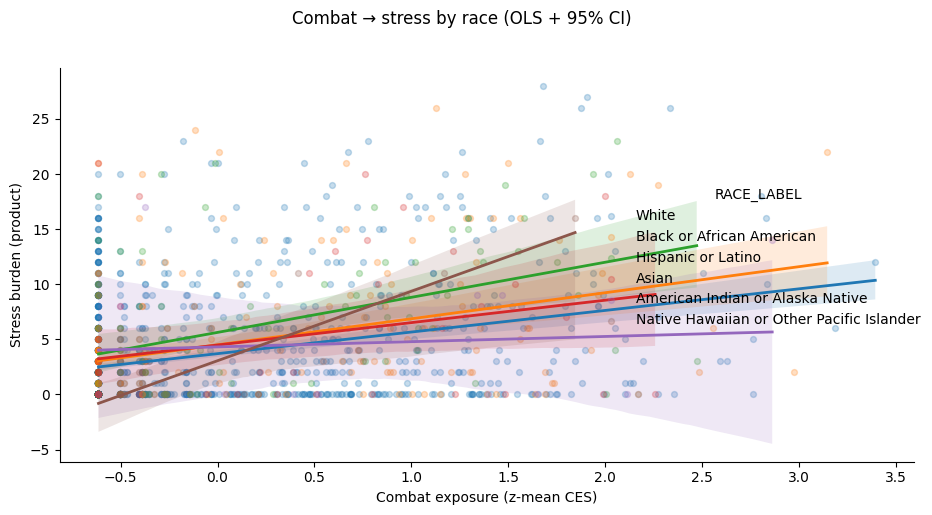

In [155]:
# Optional: combat → stress with separate OLS lines per race (95% CI)
# Requires plot_df from the cell above — re-run that cell first if needed.
g = sns.lmplot(
    data=plot_df,
    x="combat_exposure",
    y="burden_product",
    hue="RACE_LABEL",
    hue_order=race_order_plot,
    height=5,
    aspect=1.2,
    scatter_kws={"alpha": 0.25, "s": 18},
    line_kws={"linewidth": 2},
    ci=95,
    legend_out=True,
)
g.set_axis_labels("Combat exposure (z-mean CES)", "Stress burden (product)")
g.fig.suptitle("Combat → stress by race (OLS + 95% CI)", y=1.02)
plt.tight_layout()
plt.show()


## Summary

Stress burden differs significantly across racial groups (ANOVA: F = 6.77, p < 0.001), indicating variation in exposure. At the same time, stress burden strongly predicts outcomes across domains: higher burden is associated with increased suicide risk, higher PTSD symptoms, and lower psychological, physical, and social well-being (p < 0.001 across models). Importantly, the relationship between stress and outcomes is consistent across groups, with similar regression slopes and no significant interaction effects. When stress burden is included in the model, racial differences in outcomes are reduced; for example, coefficients for non-White groups move toward zero after adjustment, indicating that part of the disparity is explained by stress exposure. Together, these results support an exposure-based explanation in which disparities arise because groups experience different levels of stress, rather than because stress affects groups differently.

Differences in stress burden across groups appear to be rooted in differences in exposure to combat-related experiences. A composite measure of combat exposure, constructed as the mean of standardized combat exposure items, differs significantly by race (ANOVA: F = 8.46, p < 0.001, R² = 0.028). On average, White respondents report slightly below-average exposure (M = −0.07), while all other groups report higher exposure, including Black respondents (M = 0.13), Hispanic respondents (M = 0.28), Asian respondents (M = 0.28), and Native Hawaiian or Other Pacific Islander respondents (M = 0.24). Notably, American Indian or Alaska Native respondents report substantially higher exposure (M = 0.80), nearly a full standard deviation above the sample mean. These differences indicate that groups are not only experiencing different levels of aggregate stress, but are also exposed to different frequencies and intensities of combat-related stressors.

Taken together with earlier findings that stress burden strongly predicts outcomes and operates similarly across groups, these results suggest that disparities may originate upstream, in differential exposure to stressful environments. That is, higher levels of combat exposure likely contribute to increased stress burden, which in turn drives differences in mental health and well-being outcomes.

In [156]:
try:
    import statsmodels.formula.api as smf
    from statsmodels.stats.anova import anova_lm
except ImportError as e:
    raise ImportError("pip install statsmodels") from e

import numpy as np
import textwrap

race_map = {
    1: "White",
    2: "Black or African American",
    3: "Hispanic or Latino",
    4: "Asian",
    5: "American Indian or Alaska Native",
    6: "Native Hawaiian or Other Pacific Islander",
}
race_order = [race_map[k] for k in sorted(race_map.keys())]
REF = "White"

stress_yes = [f"STRESS_{i}" for i in range(1, 8)]
stress_a_cols = [f"STRESS_{i}A" for i in range(1, 8)]

OUTCOMES = [
    ("SBQ_TOTAL", "Suicide risk (SBQ total; higher = greater suicide risk)"),
    ("MISSSF_TOTAL", "PTSD-related symptoms (MISS-SF total; higher = more symptoms)"),
    (
        "PSY",
        "Emotional / psychological QoL (WL PSY; higher = better mental well-being)",
    ),
    (
        "PH",
        "Physical / functional QoL (WHOQOL PH; higher = better; proxy for capacity/work role)",
    ),
    (
        "SOCREL",
        "Social functioning (WHOQOL social relationships; higher = better)",
    ),
]

outcome_cols = [c for c, _ in OUTCOMES]
cols = ["RACE"] + stress_yes + stress_a_cols + outcome_cols
wide = df[cols].copy()
wide["RACE"] = pd.to_numeric(wide["RACE"], errors="coerce")
for c in stress_yes + stress_a_cols + outcome_cols:
    wide[c] = pd.to_numeric(wide[c], errors="coerce")

wide["n_stressors"] = (wide[stress_yes] == 1).sum(axis=1)
wide["stress_index"] = wide[stress_a_cols].mean(axis=1, skipna=True)
wide["burden_product"] = np.where(
    wide["n_stressors"].to_numpy() == 0,
    0.0,
    wide["n_stressors"].to_numpy() * wide["stress_index"].to_numpy(),
)

wide = wide.dropna(subset=["RACE", "burden_product"])
wide = wide[wide["RACE"].isin(race_map.keys())].copy()
wide["RACE_LABEL"] = wide["RACE"].astype(int).map(race_map)

pal = sns.color_palette("Set2", n_colors=len(race_order))
color_map = dict(zip(race_order, pal))


def print_three_step_models(data, y: str, y_label: str):
    d = data.dropna(subset=[y, "burden_product"]).copy()
    print("
" + "=" * 80)
    print(y_label)
    print("=" * 80)
    print(f"Listwise N = {len(d)}")

    print("
(1) Does race differ on Y?   Y ~ race")
    m_race = smf.ols(
        f"{y} ~ C(RACE_LABEL, Treatment(reference="{REF}"))",
        data=d,
    ).fit()
    print(f"R² = {m_race.rsquared:.4f}")
    print(anova_lm(m_race, typ=2))

    print("
(2) Does burden predict Y?   Y ~ burden_product")
    m_b = smf.ols(f"{y} ~ burden_product", data=d).fit()
    print(m_b.summary().tables[1])
    print(f"R² = {m_b.rsquared:.4f}")

    print("
(3) Does burden explain racial differences?   Y ~ burden_product + race")
    m_adj = smf.ols(
        f"{y} ~ burden_product + C(RACE_LABEL, Treatment(reference="{REF}"))",
        data=d,
    ).fit()
    print(f"R² (adjusted) = {m_adj.rsquared:}")
    print(anova_lm(m_adj, typ=2))

    print("
--- Race coefficients vs White: Y~race only  vs  Y~burden+race ---")
    c0 = m_race.params.drop("Intercept")
    c1 = m_adj.params.drop(["Intercept", "burden_product"])
    common = c0.index.intersection(c1.index)
    tab = pd.DataFrame({"coef_race_only": c0.loc[common], "coef_adj_burden": c1.loc[common]})
    tab["change"] = tab["coef_adj_burden"] - tab["coef_race_only"]
    print(tab.round(4).to_string())
    print(
        "
Negative change (toward 0) suggests burden accounts for part of the racial gap in Y "
        "(sign depends on scale direction; compare magnitudes)."
    )


def plot_burden_outcome_grid(data, outcomes):
    n_rows = len(outcomes)
    fig, axes = plt.subplots(
        n_rows,
        2,
        figsize=(20, 5 * n_rows),
        gridspec_kw={"width_ratios": [1.0, 1.35]},
        constrained_layout=True,
    )

    if n_rows == 1:
        axes = np.array([axes])

    for i, (y, y_label) in enumerate(outcomes):
        d = data.dropna(subset=[y, "burden_product"]).copy()

        ax_box = axes[i, 0]
        sns.boxplot(
            data=d,
            x="RACE_LABEL",
            y="burden_product",
            order=race_order,
            ax=ax_box,
            hue="RACE_LABEL",
            palette=color_map,
            dodge=False,
            linewidth=1,
            fliersize=2,
        )
        if ax_box.get_legend() is not None:
            ax_box.get_legend().remove()
        ax_box.set_title(f"{y}: Stress burden by race")
        ax_box.set_xlabel("")
        ax_box.set_ylabel("burden_product")
        ax_box.tick_params(axis="x", rotation=22)

        ax = axes[i, 1]
        for race in race_order:
            sub = d[d["RACE_LABEL"] == race]
            c = color_map[race]
            ax.scatter(
                sub["burden_product"],
                sub[y],
                color=c,
                alpha=0.28,
                s=22,
                edgecolors="none",
                label=race,
            )
            if len(sub) >= 8:
                coef = np.polyfit(sub["burden_product"], sub[y], 1)
                xg = np.linspace(sub["burden_product"].min(), sub["burden_product"].max(), 80)
                ax.plot(xg, np.poly1d(coef)(xg), color=c, linewidth=2.2)

        ax.set_xlabel("burden_product (# stressors × mean STRESS_*A)")
        ax.set_ylabel(y)
        ax.set_title(f"{y} vs burden by race (OLS lines per group)")
        ax.grid(alpha=0.25)

        if i == 0:
            ax.legend(title="Race", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)

        row_title = "
".join(textwrap.wrap(y_label, width=90))
        ax_box.text(
            0.0,
            1.16,
            row_title,
            transform=ax_box.transAxes,
            ha="left",
            va="bottom",
            fontsize=10,
            fontweight="bold",
        )

    fig.suptitle(
        "Race -> Stress burden -> Outcomes (paired plots by outcome)",
        fontsize=14,
        y=1.02,
    )
    plt.show()


for ycol, ylab in OUTCOMES:
    print_three_step_models(wide, ycol, ylab)

plot_burden_outcome_grid(wide, OUTCOMES)


SyntaxError: unterminated string literal (detected at line 66) (1556470573.py, line 66)